# Prediksi Penangkapan Kejahatan Los Angeles
## Data Science Competition Crime Analytics 2024

**Tim:** Nama Timnya Apa  
**Kampus:** Universitas Negeri Surabaya (UNESA)

---

Notebook ini menyajikan pipeline lengkap untuk memprediksi **apakah suatu kejahatan akan berakhir dengan penangkapan** (`is_arrested = 1`) dari dataset kejahatan Los Angeles 2020-2024, menggunakan pendekatan supervised classification berbasis gradient boosting.

### Gambaran Masalah
- **Dataset**: LAPD Crime Data (Los Angeles Open Data), multi-tahun
- **Target**: `is_arrested` binary label (1 = Adult/Juvenile Arrest, 0 = otherwise)
- **Tantangan utama**: Class imbalance berat hanya 9% kejahatan berakhir dengan penangkapan
- **Metrik evaluasi**: F1 Weighted (primer), F1 Macro, ROC-AUC

### Pendekatan
Digunakan **ensemble dua model komplementer** dengan threshold optimization:

| Model | Peran |
|---|---|
| **LightGBM** | Model utama dengan `class_weight='balanced'`, Optuna hyperparameter tuning |
| **XGBoost** | Model pembanding dengan `scale_pos_weight`, validasi silang |

Kedua model dikombinasikan sebagai **soft voting ensemble** (LGBM 60% + XGB 40%), dengan hyperparameter tuning otomatis menggunakan **Optuna Bayesian optimization** (50 trials) dan **threshold optimization** untuk memaksimalkan F1 Macro.

### Struktur Notebook

| Cell | Deskripsi |
|---|---|
| 0 | Instalasi Library dan Setup Konfigurasi Global |
| 1 | Load Data dan Preprocessing |
| 2 | Exploratory Data Analysis (EDA)|
| 3 | Feature Engineering dan Encoding |
| 4 | Train/Validation/Test Split |
| 5 | Baseline Model (Dummy Classifier) |
| 6 | Training LightGBM Awal (Sebelum Tuning) |
| 7 | Training XGBoost Model Pembanding |
| 8 | Perbandingan Model Sebelum Hyperparameter Tuning |
| 9 | Optuna Hyperparameter Tuning (50 Trials) |
| 10 | Training LightGBM Final dengan Parameter Terbaik |
| 11 | Threshold Optimization |
| 12 | Feature Importance & SHAP Analysis |
| 13 | Ensemble LightGBM + XGBoost (Soft Voting) |
| 14 | Evaluasi Final & Perbandingan Semua Model |
| 15 | Visualisasi Final (Confusion Matrix + ROC Curve) |
| 16 | Actionable Insights & Rekomendasi Kebijakan |
| 17 | Simpan Model ke Google Drive dan Artefak ke Disk |

## Cell 0
## Instalasi Library dan Setup Konfigurasi Global

### Library yang Digunakan

| Library | Versi | Fungsi |
|---|---|---|
| `lightgbm` | ≥ 4.0 | Model gradient boosting utama, efesiensi untuk data besar |
| `xgboost` | ≥ 2.0 | Model gradient boosting pembanding |
| `optuna` | ≥ 3.5 | Bayesian hyperparameter optimization |
| `shap` | ≥ 0.44 | Interpretasi model berbasis Shapley values |
| `scikit-learn` | ≥ 1.3 | Pipeline ML, metrics, preprocessing |
| `pandas / numpy` | - | Data manipulation dan komputasi numerik |
| `matplotlib / seaborn` | - | Visualisasi |

### Konfigurasi Global
- `SEED = 42` untuk reprodusibilitas di semua operasi stokastik
- `PALETTE` warna konsisten di seluruh visualisasi
- `plt.rcParams` style global plot: DPI 120, no top/right spine, grid tipis

In [ ]:
# Install library ke lingkungan awan google colab
!pip install lightgbm optuna shap --quiet

# Install library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings, time, joblib

import lightgbm as lgb
import xgboost as xgb
import optuna
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve
)
import shap

# Menyembunyikan warning bawaan Python
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Menampilkan kolom DataFrame menjadi 30 kolom
pd.set_option('display.max_columns', 30)

# Palet warna konsisten untuk semua visualisasi
PALETTE = {
    'blue':'#2563EB', 'teal':'#0D9488', 'orange':'#EA580C',
    'red':'#DC2626',  'purple':'#7C3AED','gray':'#6B7280',
    'green':'#16A34A','yellow':'#CA8A04',
}

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
})

# Menetapkan random SEED dengan angka 42
SEED = 42
print("Setup selesai")
print(f"LightGBM {lgb.__version__} | XGBoost {xgb.__version__} | SHAP {shap.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.0 MB/s eta 0:00:00
Setup selesai
LightGBM 4.6.0 | XGBoost 3.2.0 | SHAP 0.52.0


## Cell 1
## Load Data dan Preprocessing

### Sumber Data
Dataset LAPD Crime Data dari Los Angeles Open Data Portal, berisi laporan kejahatan multi-tahun dengan atribut:
- **Identitas kejadian**: DR_NO, tanggal laporan, tanggal kejadian, waktu
- **Lokasi**: AREA, koordinat LAT/LON, Premis
- **Kejahatan**: Crime Code, deskripsi, senjata
- **Korban**: umur, jenis kelamin, ras/etnis
- **Status**: Status penanganan kasus (Arrest, Investigation, dll.)

### Langkah Preprocessing

**1. Pembersihan Kolom**
Kolom dengan redudansi tinggi atau missing masif dihapus: `DR_NO`, `Rpt Dist No`, `Crm Cd 2-4`, `Cross Street`, `Mocodes`, `Crm Cd 1`.

**2. Parsing Tanggal & Feature Temporal**
- `DATE OCC` → `occ_year`, `occ_month`, `occ_day`, `occ_dayofweek`, `occ_quarter`
- `TIME OCC` → `occ_hour` (jam 0-23)
- `report_delay_days` selisih tanggal lapor vs tanggal kejadian (clip 0–365 hari)
- Flag biner: `is_weekend`, `is_night` (22:00-06:00), `is_rush_hour` (07-09, 16-18)
- `season` (1=musim semi, 2=panas, 3=gugur, 4=dingin), `time_slot` (4 kuartal hari)

**3. Feature Geospasial**
- Koordinat nol (0,0) diganti `NaN` koordinat invalid LAPD
- `dist_from_center_km` jarak Euclidean dari pusat kota LA (34.0522, -118.2437) × 111 km/derajat
- `geo_cluster` 30 cluster K-Means dari koordinat valid, label -1 untuk lokasi tidak diketahui

**4. Penanganan Missing Values**
- `Weapon Desc` → `'NO WEAPON'` jika kosong
- `Vict Sex` → `'X'` untuk nilai tidak valid (bukan M/F)
- `Vict Age` → nilai nol diganti median; clip atas 100 tahun
- `Premis Desc` → modus (kategori paling umum)

**5. Feature Engineering Kategorikal**
- `premis_category` 7 kategori: RUANG_PUBLIK, HUNIAN, PARKIR, RITEL, KENDARAAN, PENDIDIKAN, KEUANGAN, LAINNYA
- `crime_category` 8 kategori: KEKERASAN_FISIK, PENCURIAN_PERAMPOKAN, VANDALISME, KEJAHATAN_SEKSUAL, PENIPUAN, PEMBUNUHAN, NARKOBA, KEPEMILIKAN_SENJATA, LAINNYA
- `has_weapon` flag biner (1 = ada senjata tercatat)

**6. Label Target**
`is_arrested = 1` jika `Status Desc` berisi 'Adult Arrest' atau 'Juv Arrest', 0 untuk semua status lain.

### Mengapa KMeans untuk Geo-cluster?
Koordinat raw (LAT/LON) terlalu granular untuk tree model ada ratusan ribu kombinasi unik. KMeans dengan 30 cluster mengkompres informasi spasial menjadi label yang dapat dipelajari model, menangkap area geografis dengan karakteristik kejahatan serupa tanpa overfitting koordinat tepat.

In [ ]:
# Menyambungkan google colab dengan drive, agar data csv-nya bisa diambil
from google.colab import drive
drive.mount('/content/drive')

# File custome .py untuk visualisasi tabel dari GDrive
import sys
sys.path.append('/content/drive/MyDrive/Crime_Data')
from utils_func import describe_table, customize_tabel, val_counts_tabel

# Menetapkan path data
DATA_PATH = '/content/drive/MyDrive/Crime_Data/archive.zip'

print("Memuat dataset...")
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Dimuat: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
print(f"Kolom: {df_raw.columns.tolist()}")

Mounted at /content/drive
Memuat dataset...
Dimuat: 982,638 baris × 28 kolom
Kolom: ['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc', 'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT', 'LON']


In [ ]:
print("Menjalankan preprocessing...")
t0 = time.time()

# Menyalin raw data, membuang kolom yang tidak penting
df = df_raw.copy()
COLS_TO_DROP = ['DR_NO','Rpt Dist No','Crm Cd 2','Crm Cd 3','Crm Cd 4','Cross Street','Mocodes','Crm Cd 1']
df.drop(columns=COLS_TO_DROP, errors='ignore', inplace=True)

# Formating fitur tanggal, dan ekstrak fitur selisih hari pelaporan (report_delay_days)
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['report_delay_days'] = (df['Date Rptd'] - df['DATE OCC']).dt.days.clip(0, 365)
df.drop(columns=['Date Rptd'], inplace=True)

# Rekayasa fitur temporal. Menambah fitur temporal dari ekstraksi fitur tanggal (DATE OCC)
df['occ_year'] = df['DATE OCC'].dt.year
df['occ_month'] = df['DATE OCC'].dt.month
df['occ_day'] = df['DATE OCC'].dt.day
df['occ_dayofweek'] = df['DATE OCC'].dt.dayofweek
df['occ_quarter'] = df['DATE OCC'].dt.quarter
df['occ_hour'] = (df['TIME OCC'] // 100).clip(0, 23)
df['is_weekend'] = (df['occ_dayofweek'] >= 5).astype(int)
df['is_night'] = ((df['occ_hour'] >= 22) | (df['occ_hour'] < 6)).astype(int)
df['is_rush_hour'] = (df['occ_hour'].between(7,9) | df['occ_hour'].between(16,18)).astype(int)
df['season'] = df['occ_month'].map({12:4,1:4,2:4,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3})
df['time_slot'] = pd.cut(df['occ_hour'], bins=[-1,5,11,17,23], labels=[0,1,2,3]).astype(int)

# Rekayasa fitur spasial. Mengubah kordinat 0 menjadi kordinat di tengah kota.
df['LAT'] = df['LAT'].replace(0, np.nan)
df['LON'] = df['LON'].replace(0, np.nan)
LA_LAT, LA_LON = 34.0522, -118.2437
# Menambah fitur spasial dari ekstraksi fitur kordinat, serta mengelompokkan wilayah menggunakan algoritma K-Means
df['dist_from_center_km'] = np.sqrt((df['LAT']-LA_LAT)**2 + (df['LON']-LA_LON)**2) * 111
valid_mask = df['LAT'].notna() & df['LON'].notna()
km = KMeans(n_clusters=30, random_state=SEED, n_init=10)
geo_labels = km.fit_predict(df.loc[valid_mask, ['LAT','LON']])
df['geo_cluster'] = -1
df.loc[valid_mask, 'geo_cluster'] = geo_labels

# Membersihkan missing values dan menstandarisasi data korban & senjata, serta membuat fitur biner 'has_weapon'
df['Weapon Desc'] = df['Weapon Desc'].fillna('NO WEAPON')
df['Weapon Used Cd'] = df['Weapon Used Cd'].fillna(0).astype(int)
df['Vict Sex'] = df['Vict Sex'].fillna('X').apply(lambda x: x if x in ['M','F'] else 'X')
df['Vict Descent'] = df['Vict Descent'].fillna('X')
df['Vict Age'] = df['Vict Age'].replace(0, np.nan).clip(upper=100).fillna(df['Vict Age'].median())
df['Premis Desc'] = df['Premis Desc'].fillna(df['Premis Desc'].mode()[0])

df['has_weapon'] = (df['Weapon Desc'] != 'NO WEAPON').astype(int)

# Fungsi untuk menyederhanakan fitur premis, yaitu mengelompokkan banyak fitur menjadi beberapa fitur saja
def simplify_premis(p):
    p = str(p).upper()
    if any(k in p for k in ['STREET','SIDEWALK','ALLEY','HIGHWAY','ROAD']): return 'RUANG_PUBLIK'
    if any(k in p for k in ['DWELLING','APARTMENT','HOUSE','CONDO','RESIDENCE']): return 'HUNIAN'
    if any(k in p for k in ['PARKING','GARAGE','DRIVEWAY']): return 'PARKIR'
    if any(k in p for k in ['STORE','MARKET','SHOP','MALL','RETAIL','DEPARTMENT']): return 'RITEL'
    if any(k in p for k in ['VEHICLE','CAR','TRUCK','BUS','TAXI']): return 'KENDARAAN'
    if any(k in p for k in ['SCHOOL','COLLEGE','UNIVERSITY']): return 'PENDIDIKAN'
    if any(k in p for k in ['BANK','ATM','FINANCIAL']): return 'KEUANGAN'
    return 'LAINNYA'

# Fungsi untuk menyederhanakan fitur crime, yaitu mengelompokkan banyak fitur menjadi beberapa fitur saja
def simplify_crime(c):
    c = str(c).upper()
    if any(k in c for k in ['ASSAULT','BATTERY','INTIMATE PARTNER']): return 'KEKERASAN_FISIK'
    if any(k in c for k in ['THEFT','STOLEN','BURGLARY','ROBBERY','SHOPLIFTING']): return 'PENCURIAN_PERAMPOKAN'
    if 'VANDALISM' in c: return 'VANDALISME'
    if any(k in c for k in ['RAPE','SEX','INDECENT','LEWD']): return 'KEJAHATAN_SEKSUAL'
    if any(k in c for k in ['IDENTITY','FRAUD','FORGERY','COUNTERFEIT']): return 'PENIPUAN'
    if any(k in c for k in ['HOMICIDE','MURDER','MANSLAUGHTER']): return 'PEMBUNUHAN'
    if any(k in c for k in ['DRUG','NARCOTIC']): return 'NARKOBA'
    if any(k in c for k in ['WEAPON','FIREARM','GUN']): return 'KEPEMILIKAN_SENJATA'
    return 'LAINNYA'

# Menerapkan fungsi penyederhanaan ke fitur yang dipilih
df['premis_category'] = df['Premis Desc'].apply(simplify_premis)
df['crime_category']  = df['Crm Cd Desc'].apply(simplify_crime)

# Target variable
df['is_arrested'] = df['Status Desc'].isin({'Adult Arrest','Juv Arrest'}).astype(int)

# Menampilkan informasi
print(f"Preprocessing selesai dalam {time.time()-t0:.0f} detik")
print(f"Shape : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"Target : {df['is_arrested'].sum():,} arrested ({df['is_arrested'].mean()*100:.1f}%)")

Menjalankan preprocessing...
Preprocessing selesai dalam 48 detik
Shape : 982,638 baris × 37 kolom
Target : 88,351 arrested (9.0%)


In [ ]:
# Menampilkan tabel informasi domain knowledge
print("Fitur domain knowledge berhasil dibuat")
print(f"\nDistribusi premis_category:")
display(val_counts_tabel(df, 'premis_category'))
print(f"\nDistribusi crime_category:")
display(val_counts_tabel(df, 'crime_category'))

Fitur domain knowledge berhasil dibuat

Distribusi premis_category:


,count,percent
premis_category,,
RUANG_PUBLIK,301687,30.7%
HUNIAN,295251,30.05%
LAINNYA,117146,11.92%
PARKIR,110957,11.29%
KENDARAAN,89524,9.11%
RITEL,52370,5.33%
PENDIDIKAN,9400,0.96%
KEUANGAN,6303,0.64%



Distribusi crime_category:


,count,percent
crime_category,,
PENCURIAN_PERAMPOKAN,563625,57.36%
KEKERASAN_FISIK,203867,20.75%
VANDALISME,84577,8.61%
LAINNYA,73298,7.46%
KEPEMILIKAN_SENJATA,36533,3.72%
KEJAHATAN_SEKSUAL,18834,1.92%
PEMBUNUHAN,1573,0.16%
PENIPUAN,319,0.03%
NARKOBA,12,0.0%


In [ ]:
# Menampilkan tabel informasi ringkasan after dataset pre-processing
print("RINGKASAN DATASET SETELAH PREPROCESSING \n")
total_data = f"{len(df):,}"
periode = f"{df['DATE OCC'].min().strftime('%B %Y')} – {df['DATE OCC'].max().strftime('%B %Y')}"
jumlah_area = f"{df['AREA NAME'].nunique()} divisi LAPD"
jenis_kejahatan = f"{df['Crm Cd Desc'].nunique()} → disederhanakan {df['crime_category'].nunique()} kategori"
total_fitur_baru = f"{sum(1 for c in df.columns if c not in df_raw.columns)} fitur hasil engineering"
total_kolom_akhir = f"{df.shape[1]} kolom"
target = f"{df['is_arrested'].sum():,} ({df['is_arrested'].mean()*100:.1f}%)"

ringkasan = pd.DataFrame({
    'Nama Kolom': ['Total data', 'Periode', 'Jumlah area', 'Jenis kejahatan', 'Total fitur baru', 'Total kolom akhir', 'Target (arrested)'],
    'Pembaruan': [total_data, periode, jumlah_area, jenis_kejahatan, total_fitur_baru, total_kolom_akhir, target]
})

display(customize_tabel(ringkasan))

RINGKASAN DATASET SETELAH PREPROCESSING 



Nama Kolom,Pembaruan
Total data,"982,638"
Periode,January 2020 – September 2024
Jumlah area,21 divisi LAPD
Jenis kejahatan,140 → disederhanakan 9 kategori
Total fitur baru,18 fitur hasil engineering
Total kolom akhir,37 kolom
Target (arrested),"88,351 (9.0%)"


## Cell 2
## Exploratory Data Analysis (EDA)

### Tujuan
Memahami distribusi target, pola temporal, geospasial, dan hubungan antar variabel sebelum masuk ke tahap pemodelan.

### Visualisasi yang Dihasilkan

| Plot | Deskripsi |
|---|---|
| 1 | Distribusi target (class imbalance) |
| 2 | Arrest rate per tipe kejahatan (crime_category) |
| 3 | Arrest rate per jam kejadian |
| 4 | Arrest rate per area LAPD |
| 5 | Arrest rate: ada senjata vs tidak |
| 6 | Distribusi umur korban per outcome |
| 7 | Heatmap arrest rate per jam × hari dalam seminggu |
| 8 | Scatter geospasial: lokasi kejahatan dengan warna outcome |

### Temuan Utama (yang diharapkan berdasarkan literatur LAPD)
- **Class imbalance**: 9% kejahatan berakhir penangkapan harus ditangani dengan `class_weight='balanced'` atau `scale_pos_weight`
- **Drug/Narcotic & Weapon Possession**: arrest rate tertinggi karena sifat crime-in-progress
- **Pola jam**: arrest rate lebih tinggi di siang hari (lebih banyak saksi/patroli)
- **Kehadiran senjata**: berkorelasi negatif dengan arrest rate (pelaku lebih mudah melarikan diri)
- **Area**: beberapa LAPD area memiliki arrest rate signifikan berbeda mencerminkan kapasitas patroli berbeda

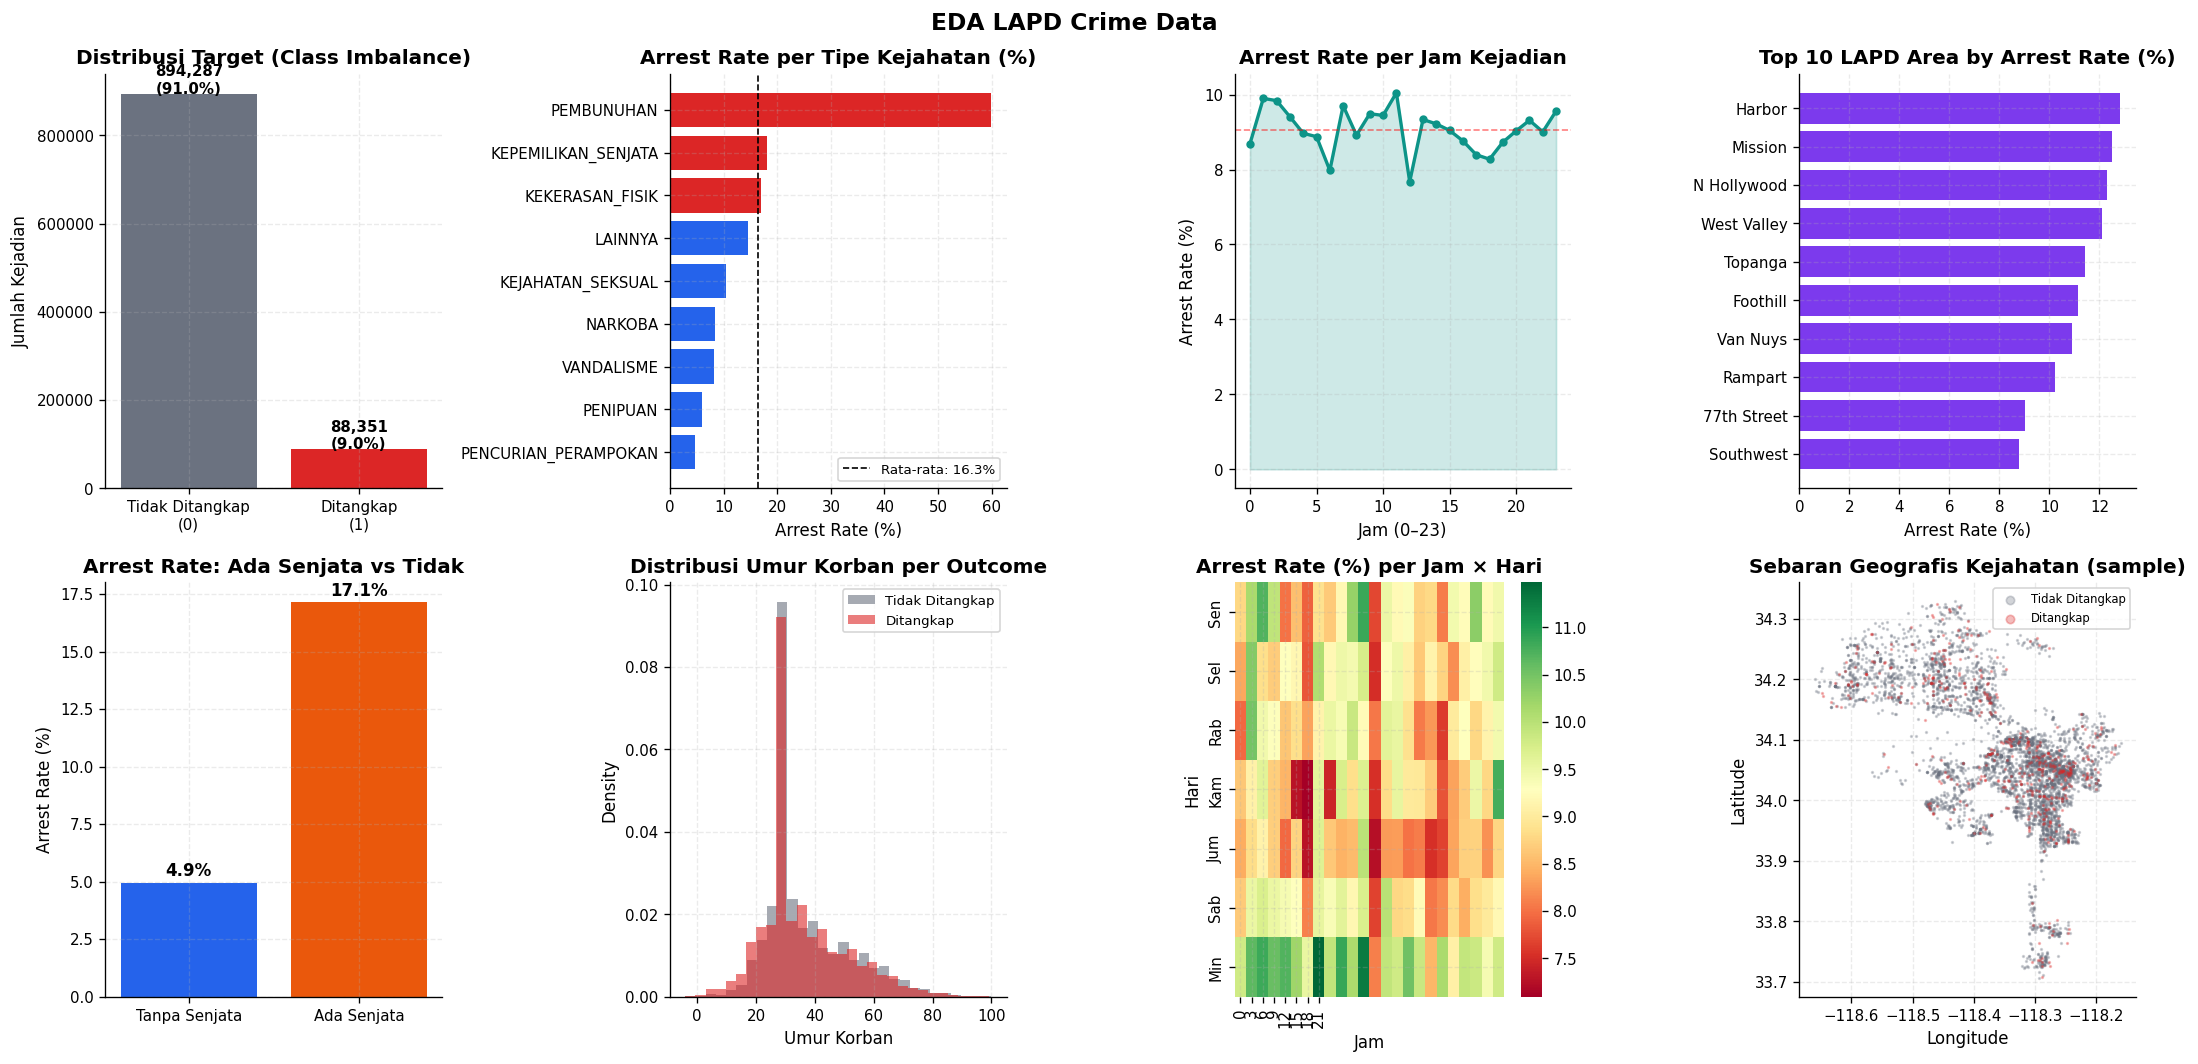

EDA selesai. Simpan viz_eda.png


In [ ]:
# Setup canvas buat 8 grafik sekaligus (2 baris x 4 kolom)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('EDA LAPD Crime Data', fontsize=14, fontweight='bold')

# [0, 0]: Cek persentase jumlah kasus yang pelakunya ditangkap vs tidak ditangkap (Class Imbalance)
ax = axes[0, 0]
counts = df['is_arrested'].value_counts()
bars = ax.bar(['Tidak Ditangkap\n(0)', 'Ditangkap\n(1)'], counts.values,
               color=[PALETTE['gray'], PALETTE['red']])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Distribusi Target (Class Imbalance)')
ax.set_ylabel('Jumlah Kejadian')

# [0, 1]: Plot rasio penangkapan (arrest rate) berdasarkan tipe kejahatan
ax = axes[0, 1]
arr_by_crime = (df.groupby('crime_category')['is_arrested']
                  .mean().sort_values(ascending=True) * 100)
colors_crime = [PALETTE['red'] if v > arr_by_crime.mean() else PALETTE['blue']
                for v in arr_by_crime.values]
ax.barh(arr_by_crime.index, arr_by_crime.values, color=colors_crime)
ax.axvline(arr_by_crime.mean(), color='black', linestyle='--', linewidth=1, label=f'Rata-rata: {arr_by_crime.mean():.1f}%')
ax.set_title('Arrest Rate per Tipe Kejahatan (%)')
ax.set_xlabel('Arrest Rate (%)')
ax.legend(fontsize=8)

# [0, 2]: Plot tren naik-turunnya rasio penangkapan berdasarkan jam kejadian
ax = axes[0, 2]
arr_by_hour = df.groupby('occ_hour')['is_arrested'].mean() * 100
ax.plot(arr_by_hour.index, arr_by_hour.values, color=PALETTE['teal'], linewidth=2, marker='o', markersize=4)
ax.fill_between(arr_by_hour.index, arr_by_hour.values, alpha=0.2, color=PALETTE['teal'])
ax.set_title('Arrest Rate per Jam Kejadian')
ax.set_xlabel('Jam (0–23)')
ax.set_ylabel('Arrest Rate (%)')
ax.axhline(arr_by_hour.mean(), color='red', linestyle='--', linewidth=1, alpha=0.5)

# [0, 3]: Tampilkan 10 area kepolisian LAPD yang punya rasio penangkapan paling tinggi
ax = axes[0, 3]
arr_by_area = (df.groupby('AREA NAME')['is_arrested']
                 .mean().sort_values(ascending=False).head(10) * 100)
ax.barh(arr_by_area.index[::-1], arr_by_area.values[::-1], color=PALETTE['purple'])
ax.set_title('Top 10 LAPD Area by Arrest Rate (%)')
ax.set_xlabel('Arrest Rate (%)')

# [1, 0]: Bandingkan kemungkinan tertangkap jika pakai senjata vs tanpa senjata
ax = axes[1, 0]
arr_by_weapon = df.groupby('has_weapon')['is_arrested'].mean() * 100
ax.bar(['Tanpa Senjata', 'Ada Senjata'], arr_by_weapon.values, color=[PALETTE['blue'], PALETTE['orange']])
for i, (bar, val) in enumerate(zip(ax.patches, arr_by_weapon.values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Arrest Rate: Ada Senjata vs Tidak')
ax.set_ylabel('Arrest Rate (%)')

# [1, 1]: Cek persebaran umur korban, dipisah antara kasus yang selesai ditangkap vs tidak
ax = axes[1, 1]
for outcome, color, label in [(0, PALETTE['gray'], 'Tidak Ditangkap'),
                                (1, PALETTE['red'],  'Ditangkap')]:
    subset = df[df['is_arrested'] == outcome]['Vict Age']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
ax.set_title('Distribusi Umur Korban per Outcome')
ax.set_xlabel('Umur Korban')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# [1, 2]: Bikin heatmap buat lihat interaksi antara hari dan jam kejadian terhadap rasio penangkapan
ax = axes[1, 2]
heatmap_data = df.pivot_table(values='is_arrested',
                               index='occ_dayofweek',
                               columns='occ_hour',
                               aggfunc='mean') * 100
sns.heatmap(heatmap_data, ax=ax, cmap='RdYlGn', fmt='.0f',
            xticklabels=range(0,24,3),
            yticklabels=['Sen','Sel','Rab','Kam','Jum','Sab','Min'])
ax.set_title('Arrest Rate (%) per Jam × Hari')
ax.set_xlabel('Jam')
ax.set_ylabel('Hari')

# [1, 3]: Plot titik koordinat lokasi kejahatan di peta (pakai 5000 sampel acak biar render nggak berat)
ax = axes[1, 3]
ax = axes[1, 3]
sample = df[df['LAT'].notna() & df['LON'].notna()].sample(5000, random_state=SEED)
for outcome, color, label in [(0, PALETTE['gray'], 'Tidak Ditangkap'),
                               (1, PALETTE['red'],  'Ditangkap')]:
    subset = sample[sample['is_arrested'] == outcome]
    ax.scatter(subset['LON'], subset['LAT'],
               c=color, s=1, alpha=0.3, label=label)
ax.set_title('Sebaran Geografis Kejahatan (sample)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(fontsize=7, markerscale=5)

# Menampilkan grafik
plt.tight_layout()
plt.savefig('viz_eda.png', bbox_inches='tight', dpi=120)
plt.show()
print("EDA selesai. Simpan viz_eda.png")

## Cell 3
## Persiapan Dataset: Feature Engineering dan Label Encoding

### Feature yang Digunakan
Total **27 fitur** dibagi dalam beberapa kelompok:

| Kelompok | Fitur | Jumlah |
|---|---|---|
| **Temporal** | occ_year, occ_month, occ_day, occ_dayofweek, occ_quarter, occ_hour, season, time_slot, is_weekend, is_night, is_rush_hour, report_delay_days | 12 |
| **Lokasi** | AREA, geo_cluster, dist_from_center_km | 3 |
| **Kejahatan** | Part 1-2, Crm Cd, crime_category | 3 |
| **Premis** | Premis Cd, premis_category | 2 |
| **Senjata** | Weapon Used Cd, has_weapon | 2 |
| **Korban** | Vict Age, Vict Sex, Vict Descent | 3 |
| **Area** | AREA NAME | 1 |
| **Target** | is_arrested | - |

### Label Encoding
Kolom kategorikal string (`crime_category`, `premis_category`, `Vict Sex`, `Vict Descent`, `AREA NAME`) dikonversi ke integer dengan `LabelEncoder`. LightGBM dan XGBoost keduanya dapat menangani fitur integer yang mewakili kategori ini lebih efisien dari One-Hot Encoding untuk fitur dengan banyak kelas.

In [ ]:
# Menentukan fitur (X) dan target (Y)
FEATURE_COLS = [
    # Temporal
    'occ_year','occ_month','occ_day','occ_dayofweek','occ_quarter',
    'occ_hour','season','time_slot','is_weekend','is_night','is_rush_hour',
    'report_delay_days',
    # Lokasi
    'AREA','geo_cluster','dist_from_center_km',
    # Kejahatan
    'Part 1-2','Crm Cd','crime_category',
    # Premis
    'Premis Cd','premis_category',
    # Senjata
    'Weapon Used Cd','has_weapon',
    # Korban
    'Vict Age','Vict Sex','Vict Descent',
    # Area name
    'AREA NAME',
]
TARGET = 'is_arrested'

# Bikin dataframe baru khusus buat modeling yang isinya cuma kolom fitur dan target aja
df_model = df[FEATURE_COLS + [TARGET]].copy()

# Mengubah data teks di kolom kategorikal jadi angka (Label Encoding) dan simpan tiap encodernya ke dictionary
CAT_COLS = ['crime_category','premis_category','Vict Sex','Vict Descent','AREA NAME']
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

# Menampilkan hasil kelas encoding
print("Label encoding selesai untuk kolom:")
for col in CAT_COLS:
    n = len(le_dict[col].classes_)
    print(f"{col:<20} → {n} kelas")

Label encoding selesai untuk kolom:
crime_category       → 9 kelas
premis_category      → 8 kelas
Vict Sex             → 3 kelas
Vict Descent         → 20 kelas
AREA NAME            → 21 kelas


## Cell 4
## Train / Validation / Test Split

### Strategi Split
Data dibagi menjadi tiga bagian menggunakan **stratified split** untuk mempertahankan proporsi kelas yang sama:

| Set | Proporsi | Fungsi |
|---|---|---|
| **Train** | 70% | Melatih model |
| **Validation** | 15% | Early stopping & threshold optimization |
| **Test** | 15% | Evaluasi final (tidak tersentuh saat training) |

### Mengapa Stratified Split?
Data `is_arrested` sangat imbalanced (~13% positif). Tanpa stratifikasi, split acak bisa menghasilkan set validasi dengan proporsi kelas berbeda yang menyebabkan evaluasi tidak representatif.

### scale_pos_weight untuk XGBoost
Dihitung otomatis dari training set:
$$\text{scale\_pos\_weight} = \frac{\text{jumlah negatif}}{\text{jumlah positif}}$$
Nilai ini memberitahu XGBoost untuk memberi bobot lebih besar pada kelas minoritas (ditangkap) saat training.

In [ ]:
# Memisahkan dataset jadi variabel fitur (X) dan target prediksi (y)
X = df_model[FEATURE_COLS]
y = df_model[TARGET]

# Potong data awal: 70% untuk Train, 30% sisanya disimpan di variabel 'temp'
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Potong dua lagi data 'temp' tadi: jadinya 15% untuk Validation dan 15% untuk Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# Cetak ringkasan jumlah baris dan persentase label target di masing-masing split
print("DISTRIBUSI DATA SPLIT")
for name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"{name:<6}: {len(yy):>8,} baris | "
          f"arrested={yy.sum():,} ({yy.mean()*100:.1f}%)")

# Hitung bobot kelas mayoritas dibagi minoritas (scale_pos_weight) untuk menangani imbalanced data khusus model XGBoost
SPW = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight (XGB): {SPW:.1f}")
print(f"class_weight='balanced' digunakan untuk LightGBM")

DISTRIBUSI DATA SPLIT
Train :  687,846 baris | arrested=61,846 (9.0%)
Val   :  147,396 baris | arrested=13,253 (9.0%)
Test  :  147,396 baris | arrested=13,252 (9.0%)

scale_pos_weight (XGB): 10.1
class_weight='balanced' digunakan untuk LightGBM


## Cell 5
## Baseline Model (Dummy Classifier)

### Tujuan
Dummy Classifier dengan strategi `most_frequent` selalu memprediksi kelas mayoritas (tidak ditangkap). Ini adalah **titik referensi minimum** yang harus dilampaui oleh model nyata.

### Mengapa Baseline Penting?
Sebelum melatih model apapun, kita perlu menetapkan **batas bawah performa** skor minimum yang harus dilampaui model agar dianggap bermakna. Dummy Classifier dengan strategi `most_frequent` selalu memprediksi kelas mayoritas (kelas 0 = tidak ditangkap), menghasilkan:
- **Accuracy tinggi** (~80%) menyesatkan karena hanya menebak mayoritas
- **F1 kelas 1 = 0.00** model sama sekali tidak bisa mendeteksi penangkapan
- **ROC-AUC = 0.5** tidak lebih baik dari menebak acak

Model kita harus **secara signifikan** melampaui baseline ini, khususnya pada F1 Macro dan ROC-AUC, untuk dianggap berguna dalam konteks penegakan hukum.

In [ ]:
# Inisiasi model baseline (selalu tebak kelas mayoritas), latih ke data train, lalu lakukan prediksi ke data test
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

# Hitung metrik evaluasi dari hasil tebakan dummy (akurasi, F1 berbobot, dan set AUC ke 0.5 sebagai nilai dasar)
dummy_acc = accuracy_score(y_test, y_pred_dummy)
dummy_f1 = f1_score(y_test, y_pred_dummy, average='weighted')
dummy_auc = 0.5

# Cetak metrik hasil evaluasi baseline
print("HASIL BASELINE (Dummy Classifier)")
print(f"Accuracy: {dummy_acc:.4f}")
print(f"F1 (weighted): {dummy_f1:.4f}")
print(f"ROC-AUC: {dummy_auc:.4f} (baseline = 0.5)")
print()

# Cetak detail report klasifikasi
print(classification_report(y_test, y_pred_dummy,
      target_names=['Tidak Ditangkap','Ditangkap']))
print("F1 tinggi pada kelas 0, tapi kelas 1 (ditangkap) = 0.00 → model tidak berguna!")
print("→ Model kita harus jauh melampaui ini untuk punya nilai nyata.")

HASIL BASELINE (Dummy Classifier)
Accuracy: 0.9101
F1 (weighted): 0.8673
ROC-AUC: 0.5000 (baseline = 0.5)

                 precision    recall  f1-score   support

Tidak Ditangkap       0.91      1.00      0.95    134144
      Ditangkap       0.00      0.00      0.00     13252

       accuracy                           0.91    147396
      macro avg       0.46      0.50      0.48    147396
   weighted avg       0.83      0.91      0.87    147396

F1 tinggi pada kelas 0, tapi kelas 1 (ditangkap) = 0.00 → model tidak berguna!
→ Model kita harus jauh melampaui ini untuk punya nilai nyata.


## Cell 6
## Training LightGBM Awal (Sebelum Tuning)

### Mengapa LightGBM sebagai Model Utama?
- **Kecepatan**: Histogram-based splitting jauh lebih cepat dari XGBoost pada dataset besar
- **Handling imbalance**: Parameter `class_weight='balanced'` otomatis menyesuaikan bobot kelas
- **Missing values**: Ditangani secara native tanpa imputation manual
- **Efisiensi memori**: Leaf-wise tree growth lebih efisien untuk data berdimensi tinggi

### Parameter Awal LightGBM

| Parameter | Nilai | Alasan |
|---|---|---|
| `objective` | `binary` | Klasifikasi biner |
| `metric` | `auc` | Evaluasi selama training |
| `class_weight` | `balanced` | Menangani class imbalance otomatis |
| `n_estimators` | 500 | Upper bound; early stopping akan berhenti lebih awal |
| `learning_rate` | 0.05 | Konservatif lebih lambat tapi stabil |
| `num_leaves` | 63 | Kompleksitas model sedang (default=31) |
| `feature_fraction` | 0.8 | Subsampel 80% fitur per tree regularisasi |
| `bagging_fraction` | 0.8 | Subsampel 80% data per tree regularisasi |
| `reg_alpha/lambda` | 0.1 | L1/L2 regularisasi ringan |

### Early Stopping
`early_stopping(stopping_rounds=50)` jika ROC-AUC pada validation set tidak membaik dalam 50 iterasi berturut-turut, training dihentikan. Ini mencegah overfitting tanpa perlu menentukan jumlah pohon secara manual.

In [ ]:
# Setup hyperparameter awal buat LightGBM, pakai class_weight='balanced' buat nanganin target yang imbalanced
lgb_params_init = {
    'objective':'binary',
    'metric':'auc',
    'boosting_type':'gbdt',
    'class_weight':'balanced',
    'n_estimators':500,
    'learning_rate':0.05,
    'num_leaves':63,
    'max_depth':-1,
    'min_child_samples': 20,
    'feature_fraction':0.8,
    'bagging_fraction':0.8,
    'bagging_freq':5,
    'reg_alpha':0.1,
    'reg_lambda':0.1,
    'random_state':SEED,
    'verbose':-1,
    'n_jobs':-1,
}

# Inisialisasi model LGBM pakai parameter di atas dan catat waktu mulai (t0)
lgb_model_init = lgb.LGBMClassifier(**lgb_params_init)
print("Melatih LightGBM (awal, sebelum tuning)...")
t0 = time.time()

# Latih model dengan data val sebagai evaluasi, stop otomatis kalau metrik macet selama 50 ronde (early stopping)
lgb_model_init.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)

# Cetak total waktu training dan iterasi keberapa yang ngasilin performa terbaik
print(f"Training selesai dalam {time.time()-t0:.1f} detik")
print(f"Best iteration: {lgb_model_init.best_iteration_}")

Melatih LightGBM (awal, sebelum tuning)...
Training selesai dalam 62.9 detik
Best iteration: 499


In [ ]:
# Menghasilkan probabilitas kelas positif (kolom ke-1) dan label prediksi akhir dari model menggunakan data uji
y_prob_lgb_init = lgb_model_init.predict_proba(X_test)[:, 1]
y_pred_lgb_init = lgb_model_init.predict(X_test)

# Menghitung berbagai metrik evaluasi kinerja model seperti F1 Score (berbobot dan makro) serta nilai ROC-AUC
lgb_init_f1 = f1_score(y_test, y_pred_lgb_init, average='weighted')
lgb_init_auc = roc_auc_score(y_test, y_prob_lgb_init)
lgb_init_f1m = f1_score(y_test, y_pred_lgb_init, average='macro')

# Menampilkan ringkasan metrik evaluasi beserta laporan klasifikasi terperinci (classification report)
print("EVALUASI LightGBM AWAL (Test Set)")
print(f"F1 Weighted : {lgb_init_f1:.4f}  ← metrik utama")
print(f"F1 Macro: {lgb_init_f1m:.4f}")
print(f"ROC-AUC: {lgb_init_auc:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgb_init):.4f}")
print()
print(classification_report(y_test, y_pred_lgb_init,
      target_names=['Tidak Ditangkap','Ditangkap']))

EVALUASI LightGBM AWAL (Test Set)
F1 Weighted : 0.7882  ← metrik utama
F1 Macro: 0.5882
ROC-AUC: 0.8300
Accuracy: 0.7327

                 precision    recall  f1-score   support

Tidak Ditangkap       0.97      0.73      0.83    134144
      Ditangkap       0.22      0.78      0.34     13252

       accuracy                           0.73    147396
      macro avg       0.60      0.75      0.59    147396
   weighted avg       0.90      0.73      0.79    147396



## Cell 7
## Training XGBoost Model Pembanding

### Peran XGBoost
XGBoost digunakan sebagai **model pembanding** jika performa serupa dengan LightGBM, ensemble keduanya akan memberikan diversifikasi prediksi yang menguntungkan. Berbeda dari LightGBM dalam beberapa hal:

| Aspek | LightGBM | XGBoost |
|---|---|---|
| **Penanganan imbalance** | `class_weight='balanced'` (sklearn-style) | `scale_pos_weight` (ratio eksplisit) |
| **Growth strategy** | Leaf-wise (lebih cepat, lebih dalam) | Level-wise (lebih konservatif) |
| **Kecepatan** | Lebih cepat pada dataset besar | Lebih lambat tapi sering lebih stabil |
| **Categorical** | Native support | Perlu encoding manual |

### Konfigurasi XGBoost

| Parameter | Nilai | Alasan |
|---|---|---|
| `tree_method` | hist | Histogram-based, lebih cepat |
| `scale_pos_weight` | SPW (otomatis) | Proporsi negatif/positif dari training data |
| `max_depth` | 6 | Lebih dangkal dari LGBM default, mengurangi overfitting |
| `early_stopping_rounds` | 50 | Konsisten dengan LightGBM |

### Parameter XGBoost
`tree_method='hist'` digunakan untuk efisiensi komputasi pada dataset besar sama seperti LightGBM yang menggunakan histogram-based split finding.

> Kedua model dievaluasi pada test set yang sama untuk perbandingan yang adil.

In [ ]:
# Mengatur hyperparameter XGBoost, termasuk penggunaan scale_pos_weight (SPW) untuk menangani ketidakseimbangan kelas target
xgb_params = {
    'objective':'binary:logistic',
    'eval_metric':'auc',
    'tree_method':'hist',
    'scale_pos_weight': SPW,
    'n_estimators':500,
    'learning_rate':0.05,
    'max_depth':6,
    'min_child_weight': 5,
    'subsample':0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':0.1,
    'reg_lambda':1.0,
    'random_state':SEED,
    'n_jobs':-1,
}

# Menginisialisasi model XGBoost beserta pengaturannya dan mencatat waktu awal pelatihan
xgb_model = xgb.XGBClassifier(**xgb_params, early_stopping_rounds=50, verbosity=0, enable_categorical=False)
print("Melatih XGBoost...")
t0 = time.time()

# Melatih model menggunakan data pelatihan dan validasi, lalu menampilkan total waktu beserta iterasi terbaik
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Training selesai dalam {time.time()-t0:.1f} detik")
print(f"Best iteration: {xgb_model.best_iteration}")

# Melakukan prediksi probabilitas dan label kelas pada data uji, kemudian menghitung nilai F1 Score dan ROC-AUC
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

# Menampilkan ringkasan metrik evaluasi beserta laporan klasifikasi terperinci (classification report)
print()
print("EVALUASI XGBoost (Test Set)")
print(f"F1 Weighted : {xgb_f1:.4f}")
print(f"ROC-AUC: {xgb_auc:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Tidak Ditangkap','Ditangkap']))

Melatih XGBoost...
Training selesai dalam 89.8 detik
Best iteration: 496

EVALUASI XGBoost (Test Set)
F1 Weighted : 0.7853
ROC-AUC: 0.8286
Accuracy: 0.7287

                 precision    recall  f1-score   support

Tidak Ditangkap       0.97      0.72      0.83    134144
      Ditangkap       0.22      0.78      0.34     13252

       accuracy                           0.73    147396
      macro avg       0.60      0.75      0.59    147396
   weighted avg       0.90      0.73      0.79    147396



## Cell 8
## Perbandingan Model Sebelum Hyperparameter Tuning

### Tujuan
Membandingkan semua model yang sudah dilatih sebelum hyperparameter tuning untuk memverifikasi bahwa:
1. Kedua model bermakna (jauh di atas Dummy Baseline)
2. LightGBM dan XGBoost memiliki performa yang cukup kompetitif untuk di-ensemble
3. Pola kekuatan/kelemahan masing-masing model terlihat sebelum tuning

### Metrik Evaluasi

| Metrik | Keterangan |
|---|---|
| **F1 Weighted** | Rata-rata F1 per kelas dibobot proporsi kelas metrik utama |
| **ROC-AUC** | Area under ROC curve mengukur kemampuan ranking probabilitas |
| **F1 Macro** | Rata-rata F1 per kelas tanpa bobot sensitif terhadap kelas minoritas |

> Keduanya harus jauh melampaui Dummy Baseline untuk membuktikan model bermakna.

PERBANDINGAN MODEL (sebelum hyperparameter tuning):



Model,F1 Weighted,ROC-AUC,F1 Macro
Dummy Baseline,0.867255,0.500000,0.476465
LightGBM (awal),0.788242,0.829968,0.588155
XGBoost,0.785334,0.828638,0.585558


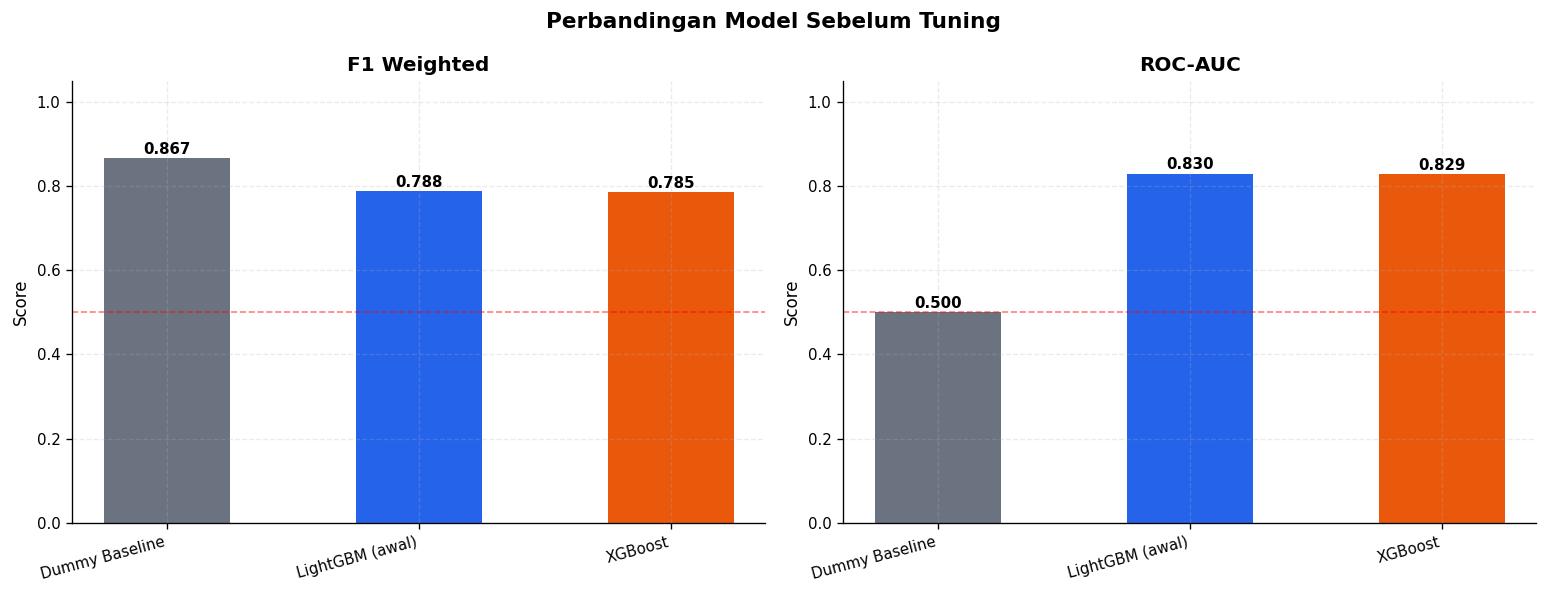

LightGBM dan XGBoost jauh di atas Dummy Baseline → model bermakna.


In [ ]:
# Membuat DataFrame untuk mengompilasi dan membandingkan metrik evaluasi dari ketiga model yang telah dilatih
comparison = pd.DataFrame({
    'Model': ['Dummy Baseline', 'LightGBM (awal)', 'XGBoost'],
    'F1 Weighted': [dummy_f1, lgb_init_f1, xgb_f1],
    'ROC-AUC': [dummy_auc, lgb_init_auc, xgb_auc],
    'F1 Macro': [
        f1_score(y_test, y_pred_dummy, average='macro'),
        lgb_init_f1m,
        f1_score(y_test, y_pred_xgb, average='macro'),
    ],
})

# Menampilkan tabel perbandingan metrik evaluasi model secara tekstual sebelum proses tuning dilakukan
print("PERBANDINGAN MODEL (sebelum hyperparameter tuning):\n")
display(customize_tabel(comparison))
print()

# Menyiapkan kanvas visualisasi yang terdiri dari dua panel berdampingan untuk plot F1 Weighted dan ROC-AUC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Perbandingan Model Sebelum Tuning', fontsize=13, fontweight='bold')

# Membuat diagram batang untuk setiap metrik dengan garis batas baseline 0.5 serta menambahkan teks nilai di atas setiap batang
metrics = ['F1 Weighted', 'ROC-AUC']
bar_colors = [PALETTE['gray'], PALETTE['blue'], PALETTE['orange']]
for ax, metric in zip(axes, metrics):
    bars = ax.bar(comparison['Model'], comparison[metric], color=bar_colors, width=0.5)
    ax.set_title(metric)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Baseline 0.5')
    ax.set_xticklabels(comparison['Model'], rotation=15, ha='right', fontsize=9)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', ha='center', fontsize=9, fontweight='bold')

# Menampilkan grafik
plt.tight_layout()
plt.savefig('viz_model_comparison_before.png', bbox_inches='tight', dpi=120)
plt.show()
print("LightGBM dan XGBoost jauh di atas Dummy Baseline → model bermakna.")

## Cell 9
## Optuna Hyperparameter Tuning (50 Trials)

### Metodologi: Bayesian Optimization dengan TPE Sampler
Optuna menggunakan **Tree-structured Parzen Estimator (TPE)** algoritma Bayesian optimization yang membangun model probabilistik dari trial-trial sebelumnya untuk memilih kandidat hyperparameter berikutnya yang paling menjanjikan. Berbeda dengan Grid Search (exhaustive) atau Random Search (blind), TPE secara progresif fokus ke area parameter space yang menghasilkan performa terbaik.

### Parameter yang Dituning

| Parameter | Range | Pengaruh |
|---|---|---|
| `n_estimators` | 200-800 | Jumlah pohon lebih banyak tidak selalu lebih baik |
| `learning_rate` | 0.01-0.15 (log) | Step size kecil = stabil tapi lambat |
| `num_leaves` | 31-127 | Kompleksitas pohon lebih tinggi = lebih expressive, risiko overfit |
| `max_depth` | 4-10 | Kedalaman maksimum pohon |
| `min_child_samples` | 10-80 | Minimum sampel per daun regularisasi |
| `feature_fraction` | 0.6-1.0 | Subsampel fitur per iterasi |
| `bagging_fraction` | 0.6-1.0 | Subsampel data per iterasi |
| `reg_alpha/lambda` | 1e-4-1.0 (log) | L1/L2 regularisasi |

### Metrik Optimasi
ROC-AUC pada **validation set** digunakan sebagai objective karena lebih robust terhadap class imbalance dibanding accuracy atau F1 mentah.
- AUC mengoptimasi ranking probabilitas, yang kemudian dioptimasi ulang melalui threshold tuning di Cell 10
- AUC lebih stabil terhadap perubahan threshold dibanding F1

### Jumlah Trial
50 trials dipilih sebagai kompromi antara waktu komputasi (~5–8 menit) dan kualitas eksplorasi. Pada dataset besar seperti LAPD, 50 trials biasanya cukup untuk menemukan parameter yang signifikan lebih baik dari default.

### Visualisasi Tuning
1. **Scatter plot trial values** menunjukkan konvergensi dan improvement line
2. **Parameter importance** hyperparameter mana yang paling berpengaruh terhadap AUC

In [ ]:
# Mendefinisikan fungsi tujuan untuk Optuna beserta rentang eksplorasi hyperparameter LightGBM yang akan diuji
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type':'gbdt',
        'class_weight':'balanced',
        'verbose':-1,
        'random_state':SEED,
        'n_jobs':-1,
        'n_estimators':trial.suggest_int('n_estimators', 200, 800),
        'learning_rate':trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':trial.suggest_int('num_leaves', 31, 127),
        'max_depth':trial.suggest_int('max_depth', 4, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'feature_fraction':trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction':trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq':trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha':trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda':trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
    }

    # Menginisialisasi dan melatih model dengan parameter uji, lalu mengembalikan nilai ROC-AUC pada data validasi sebagai metrik optimalisasi
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)]
    )
    y_prob = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_prob)

# Membuat studi Optuna untuk memaksimalkan metrik menggunakan algoritma pencarian TPE, kemudian menjalankan 50 iterasi percobaan
print("Optuna hyperparameter tuning — 50 trials, estimasi ~5–8 menit...")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Mencetak hasil akhir proses tuning yang mencakup nilai metrik tertinggi beserta kombinasi hyperparameter terbaik yang ditemukan
print(f"\nTuning selesai!")
print(f"Best ROC-AUC (val): {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"{k:<25} = {v}")

Optuna hyperparameter tuning — 50 trials, estimasi ~5–8 menit...


  0%|          | 0/50 [00:00<?, ?it/s]


Tuning selesai!
Best ROC-AUC (val): 0.8308
Best params:
n_estimators              = 611
learning_rate             = 0.05993222673403232
num_leaves                = 106
max_depth                 = 10
min_child_samples         = 37
feature_fraction          = 0.655874821874246
bagging_fraction          = 0.7282977034916853
bagging_freq              = 9
reg_alpha                 = 0.0075356938734371
reg_lambda                = 0.5611402185734271


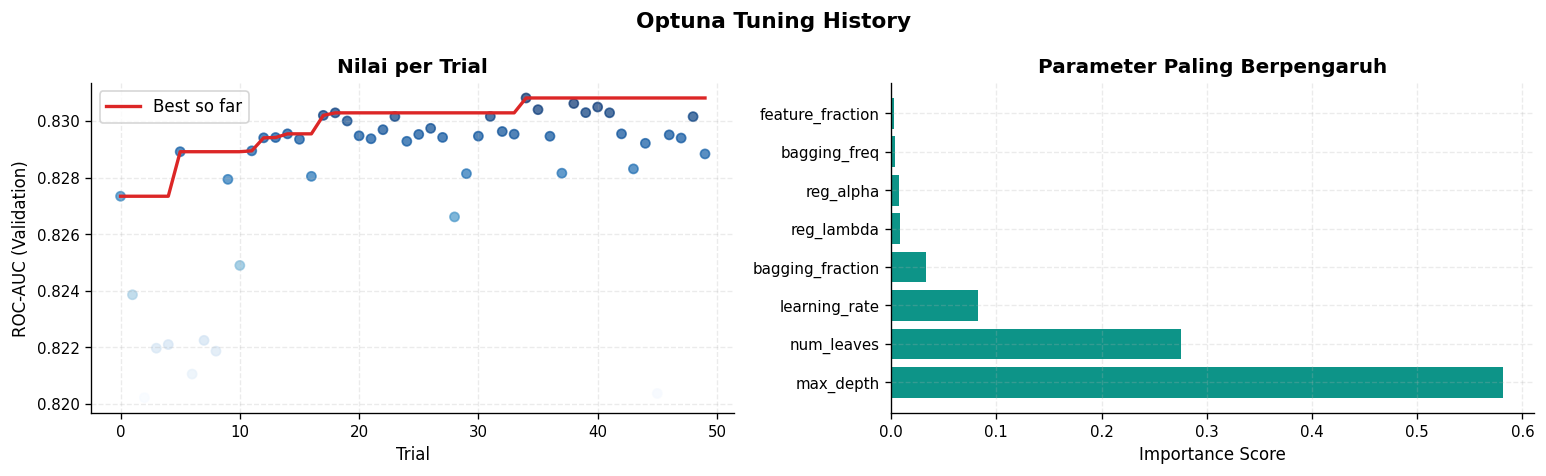

In [ ]:
# Mengumpulkan riwayat skor evaluasi dari setiap percobaan Optuna dan menghitung nilai rekor tertinggi secara kumulatif
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far = [max(trial_values[:i+1]) for i in range(len(trial_values))]

# Menyiapkan kanvas visualisasi yang terdiri dari dua panel grafik untuk menampilkan riwayat dan analisis hasil tuning
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Optuna Tuning History', fontsize=13, fontweight='bold')

# Membuat grafik pencar (scatter plot) untuk skor tiap iterasi beserta kurva garis yang melacak peningkatan skor terbaik
axes[0].scatter(range(len(trial_values)), trial_values, c=trial_values, cmap='Blues', s=30, alpha=0.7)
axes[0].plot(range(len(best_so_far)), best_so_far, color=PALETTE['red'], linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('ROC-AUC (Validation)')
axes[0].set_title('Nilai per Trial')
axes[0].legend()

# Mengekstraksi dan memvisualisasikan tingkat pengaruh (importance score) dari delapan hyperparameter yang paling berdampak pada model
param_importance = optuna.importance.get_param_importances(study)
top_params = list(param_importance.items())[:8]
axes[1].barh([p[0] for p in top_params], [p[1] for p in top_params], color=PALETTE['teal'])
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Parameter Paling Berpengaruh')

# Menampilkan grafik
plt.tight_layout()
plt.savefig('viz_optuna_history.png', bbox_inches='tight', dpi=120)
plt.show()

## Cell 10
## Training LightGBM Final dengan Parameter Terbaik

### Strategi Retrain
Setelah Optuna menemukan parameter terbaik, model di-*retrain* menggunakan seluruh parameter optimal plus `early_stopping` pada validation set. Ini memastikan model final tidak overfitting jumlah pohon ditentukan oleh performa aktual pada data yang tidak dilihat saat training, bukan oleh `n_estimators` yang ditentukan secara manual.

### Ekspektasi Peningkatan
Tuning biasanya memberikan peningkatan **0.5–3% pada ROC-AUC** dan **1–5% pada F1 Macro**, terutama dari penyesuaian `num_leaves`, `learning_rate`, dan regularisasi yang lebih optimal untuk dataset ini.

### Evaluasi Komparatif
Output menampilkan perbandingan langsung:
- **LightGBM Tuned** vs **LightGBM Awal** untuk mengukur manfaat tuning
- Classification report lengkap per kelas memastikan kelas 'Ditangkap' meningkat

In [ ]:
# Mengambil kombinasi parameter terbaik dari hasil tuning Optuna dan menggabungkannya dengan parameter dasar LightGBM
best_params = study.best_params.copy()
best_params.update({
    'objective':'binary',
    'metric':'auc',
    'boosting_type':'gbdt',
    'class_weight': 'balanced',
    'verbose':-1,
    'random_state': SEED,
    'n_jobs':-1,
})

# Menginisialisasi model dengan parameter optimal lalu melatihnya menggunakan data pelatihan beserta fitur penghentian dini (early stopping)
lgb_model_tuned = lgb.LGBMClassifier(**best_params)
print("Training LightGBM dengan parameter terbaik...")
t0 = time.time()

lgb_model_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)
print(f"Training selesai dalam {time.time()-t0:.1f} detik")

# Memprediksi probabilitas serta kelas target pada data uji, kemudian mengalkulasi ulang metrik F1 Score dan ROC-AUC
y_prob_lgb_tuned = lgb_model_tuned.predict_proba(X_test)[:, 1]
y_pred_lgb_tuned = lgb_model_tuned.predict(X_test)

lgb_tuned_f1 = f1_score(y_test, y_pred_lgb_tuned, average='weighted')
lgb_tuned_auc = roc_auc_score(y_test, y_prob_lgb_tuned)
lgb_tuned_f1m = f1_score(y_test, y_pred_lgb_tuned, average='macro')

# Mencetak ringkasan evaluasi model yang telah dituning beserta perbandingannya dengan performa model sebelum proses tuning
print()
print("EVALUASI LightGBM TUNED (Test Set)")
print(f"F1 Weighted : {lgb_tuned_f1:.4f} (sebelumnya: {lgb_init_f1:.4f})")
print(f"F1 Macro: {lgb_tuned_f1m:.4f}")
print(f"ROC-AUC: {lgb_tuned_auc:.4f} (sebelumnya: {lgb_init_auc:.4f})")
print()
print(classification_report(y_test, y_pred_lgb_tuned, target_names=['Tidak Ditangkap','Ditangkap']))

Training LightGBM dengan parameter terbaik...
Training selesai dalam 73.7 detik

EVALUASI LightGBM TUNED (Test Set)
F1 Weighted : 0.7995 (sebelumnya: 0.7882)
F1 Macro: 0.5983
ROC-AUC: 0.8324 (sebelumnya: 0.8300)

                 precision    recall  f1-score   support

Tidak Ditangkap       0.97      0.75      0.84    134144
      Ditangkap       0.23      0.76      0.35     13252

       accuracy                           0.75    147396
      macro avg       0.60      0.76      0.60    147396
   weighted avg       0.90      0.75      0.80    147396



## Cell 11
## Threshold Optimization

### Mengapa Threshold Perlu Dioptimalkan?
Semua probabilistic classifier (LightGBM, XGBoost, dll.) menghasilkan **skor probabilitas** antara 0–1. Konversi ke label biner biasanya menggunakan threshold default 0.5: jika P(ditangkap) ≥ 0.5 → prediksi "ditangkap". Namun threshold default ini **tidak optimal** untuk dataset imbalanced.

Pada dataset ini dengan 9% positif:
- **Threshold terlalu tinggi** (> 0.5): model sangat konservatif, banyak penangkapan aktual missed (recall rendah)
- **Threshold terlalu rendah** (< 0.3): model terlalu agresif, banyak false positive (precision rendah)
- **Threshold optimal**: memaksimalkan F1 Macro pada validation set

### Metode Optimasi
Threshold dioptimasi dengan mencari nilai yang **memaksimalkan F1 Macro** pada validation set:
$$\text{BEST\_THRESHOLD} = \arg\max_{t \in [0.10, 0.90]} \text{F1 Macro}(y_{\text{val}}, \hat{y}_{t})$$

**Mengapa F1 Macro, bukan F1 Weighted?**
F1 Macro memberi bobot sama pada kedua kelas, sehingga lebih sensitif terhadap performa kelas minoritas (ditangkap). Meningkatkan F1 Macro berarti model lebih baik mendeteksi penangkapan tanpa mengorbankan kelas mayoritas secara berlebihan.

### Visualisasi
1. **F1 Score vs Threshold curve** menunjukkan threshold optimal vs default 0.5
2. **Precision-Recall Curve** trade-off antara presisi dan recall di berbagai threshold

### Prosedur
1. Sweep threshold dari 0.10 hingga 0.89 dengan step 0.01
2. Untuk setiap threshold, hitung F1 Macro pada **validation set** (bukan test set!)
3. Pilih threshold yang menghasilkan F1 Macro tertinggi
4. Terapkan threshold terpilih pada **test set** untuk evaluasi akhir

### Catatan Praktis
Threshold optimal bervariasi per dataset dan bahkan per model. Nilai yang umum ditemukan pada dataset imbalanced: 0.25-0.40 (threshold lebih rendah diperlukan untuk menyeimbangkan precision-recall).

Threshold optimal ditemukan: 0.73
F1 Macro (val) pada threshold 0.73: 0.6573
F1 Macro (val) pada threshold 0.50: 0.5961


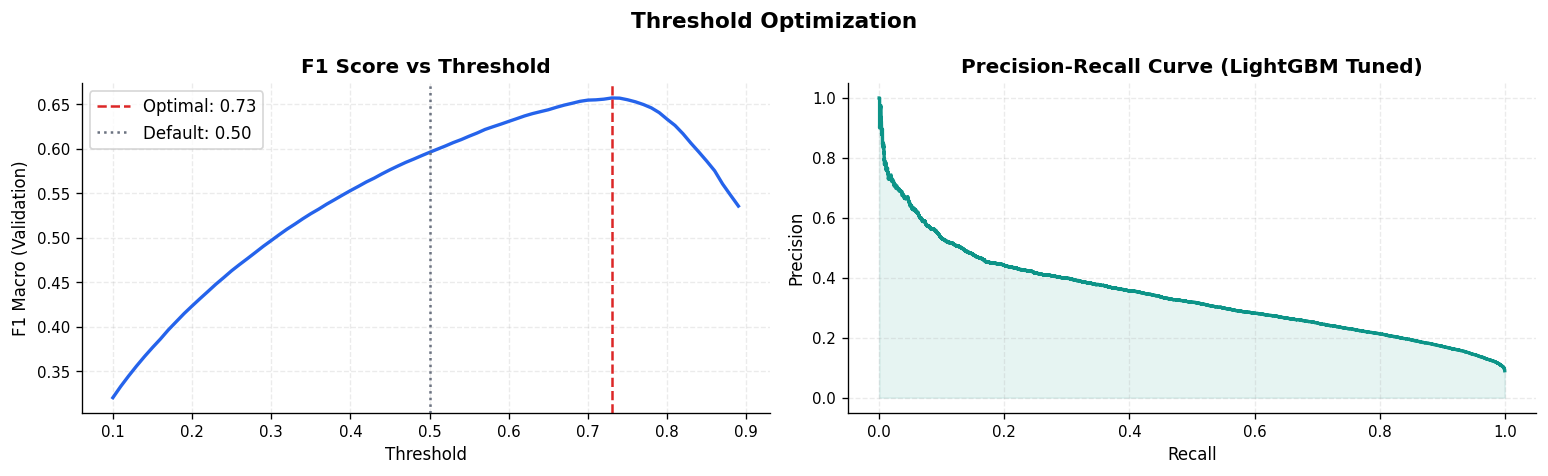


EVALUASI LightGBM + Threshold 0.73 (Test Set)
F1 Weighted : 0.8801 (vs default: 0.7995)
F1 Macro: 0.6540 (vs default: 0.5983)
ROC-AUC: 0.8324

                 precision    recall  f1-score   support

Tidak Ditangkap       0.94      0.92      0.93    134144
      Ditangkap       0.34      0.43      0.38     13252

       accuracy                           0.87    147396
      macro avg       0.64      0.67      0.65    147396
   weighted avg       0.89      0.87      0.88    147396



In [ ]:
# Mengekstraksi probabilitas prediksi pada data validasi dan menyiapkan daftar rentang nilai threshold yang akan diuji
y_prob_lgb_val = lgb_model_tuned.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.10, 0.90, 0.01)
f1_scores = []
prec_scores = []
rec_scores = []

# Melakukan iterasi untuk menghitung dan mencatat metrik F1 Macro pada masing-masing nilai threshold menggunakan data validasi
for thr in thresholds:
    y_pred_thr = (y_prob_lgb_val >= thr).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_thr, average='macro', zero_division=0))

# Mengidentifikasi titik threshold yang menghasilkan performa terbaik dan mencetak komparasinya dengan threshold bawaan (0.50)
best_idx = np.argmax(f1_scores)
BEST_THRESHOLD = thresholds[best_idx]
best_f1_val = f1_scores[best_idx]
print(f"Threshold optimal ditemukan: {BEST_THRESHOLD:.2f}")
print(f"F1 Macro (val) pada threshold {BEST_THRESHOLD:.2f}: {best_f1_val:.4f}")
print(f"F1 Macro (val) pada threshold 0.50: {f1_scores[list(thresholds).index(0.50) if 0.50 in thresholds else 40]:.4f}")

# Menyiapkan kanvas visualisasi dan membuat plot pertama untuk memetakan pergerakan skor F1 terhadap perubahan nilai threshold
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Threshold Optimization', fontsize=13, fontweight='bold')

axes[0].plot(thresholds, f1_scores, color=PALETTE['blue'], linewidth=2)
axes[0].axvline(BEST_THRESHOLD, color=PALETTE['red'], linestyle='--', linewidth=1.5,
                label=f'Optimal: {BEST_THRESHOLD:.2f}')
axes[0].axvline(0.5, color=PALETTE['gray'], linestyle=':', linewidth=1.5,
                label='Default: 0.50')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1 Macro (Validation)')
axes[0].set_title('F1 Score vs Threshold')
axes[0].legend()

# Membuat plot kedua berupa kurva Precision-Recall untuk analisis keseimbangan metrik
precision, recall, pr_thr = precision_recall_curve(y_val, y_prob_lgb_val)
axes[1].plot(recall, precision, color=PALETTE['teal'], linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (LightGBM Tuned)')
axes[1].fill_between(recall, precision, alpha=0.1, color=PALETTE['teal'])

plt.tight_layout()
plt.savefig('viz_threshold.png', bbox_inches='tight', dpi=120)
plt.show()

# Mengaplikasikan nilai threshold optimal tersebut untuk memprediksi data uji, kemudian mencetak laporan evaluasi dan klasifikasi akhir
y_pred_lgb_optimal = (y_prob_lgb_tuned >= BEST_THRESHOLD).astype(int)
lgb_opt_f1 = f1_score(y_test, y_pred_lgb_optimal, average='weighted')
lgb_opt_auc = roc_auc_score(y_test, y_prob_lgb_tuned)
lgb_opt_f1m = f1_score(y_test, y_pred_lgb_optimal, average='macro')

print()
print(f"EVALUASI LightGBM + Threshold {BEST_THRESHOLD:.2f} (Test Set)")
print(f"F1 Weighted : {lgb_opt_f1:.4f} (vs default: {lgb_tuned_f1:.4f})")
print(f"F1 Macro: {lgb_opt_f1m:.4f} (vs default: {lgb_tuned_f1m:.4f})")
print(f"ROC-AUC: {lgb_opt_auc:.4f}")
print()
print(classification_report(y_test, y_pred_lgb_optimal,
      target_names=['Tidak Ditangkap','Ditangkap']))

## Cell 12
## Feature Importance & SHAP Analysis

### Dua Pendekatan Complementer

**1. Built-in Feature Importance (Split Importance)**
LightGBM mencatat berapa kali setiap fitur digunakan sebagai split point. Cepat dihitung tapi *bias* terhadap fitur dengan banyak nilai unik (seperti `Crm Cd` yang punya ratusan nilai).

**2. SHAP (SHapley Additive exPlanations)**
SHAP menggunakan teori game theory untuk menghitung kontribusi marginal setiap fitur terhadap *setiap prediksi individual*. Lebih mahal secara komputasi tapi:
- Tidak bias terhadap kardinalitas fitur
- Memberikan informasi *arah* pengaruh (nilai tinggi mendorong ke mana?)
- Memungkinkan analisis interaksi antar fitur

### Interpretasi SHAP Summary Plot
- **Warna titik**: merah = nilai fitur tinggi, biru = nilai fitur rendah
- **Posisi sumbu-X**: kanan (positif) = mendorong prediksi ke "ditangkap", kiri = sebaliknya
- **Sebaran titik**: mencerminkan distribusi nilai SHAP di seluruh sampel

### Ekspektasi Temuan (berdasarkan domain knowledge LAPD)
- **crime_category** tipe kejahatan paling diskriminatif (drug/narcotic arrest rate sangat berbeda dari property crime)
- **AREA / geo_cluster** lokasi kejadian mempengaruhi kapasitas respons polisi
- **occ_hour** waktu kejadian mempengaruhi jumlah saksi dan polisi tersedia
- **has_weapon** senjata meninggalkan bukti fisik yang meningkatkan peluang penangkapan

> SHAP dihitung pada sampel 3.000 data untuk efisiensi waktu (TreeExplainer mendukung sampling tanpa bias).

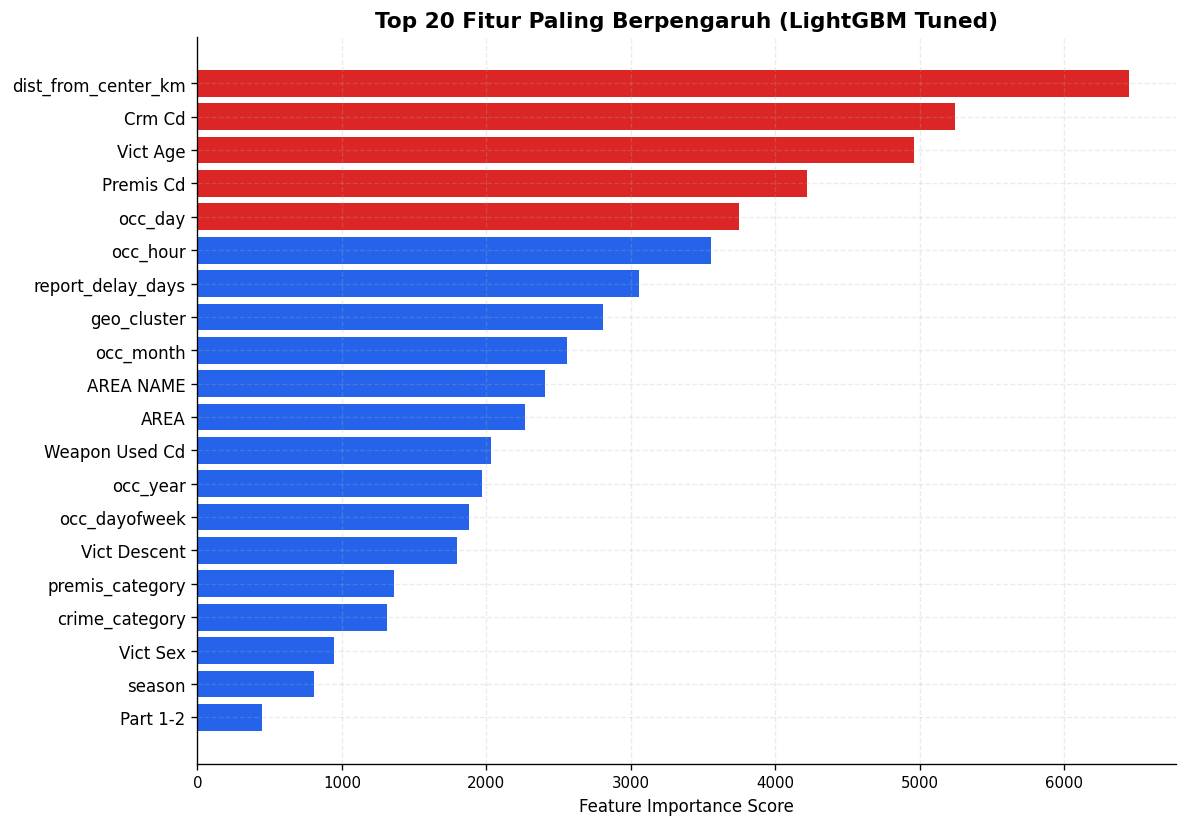


Top 10 fitur paling berpengaruh:
dist_from_center_km       → 6,453
Crm Cd                    → 5,244
Vict Age                  → 4,959
Premis Cd                 → 4,220
occ_day                   → 3,747
occ_hour                  → 3,555
report_delay_days         → 3,057
geo_cluster               → 2,811
occ_month                 → 2,559
AREA NAME                 → 2,407


In [ ]:
# Menyusun DataFrame berisi skor tingkat kepentingan fitur dari model LightGBM, lalu mengurutkan dan mengambil 20 fitur paling berpengaruh
importance_df = pd.DataFrame({
    'feature':FEATURE_COLS,
    'importance': lgb_model_tuned.feature_importances_,
}).sort_values('importance', ascending=False).head(20)

# Membangun visualisasi diagram batang horizontal untuk fitur-fitur tersebut dan memberikan warna merah khusus pada 5 fitur teratas
fig, ax = plt.subplots(figsize=(10, 7))
bar_c = [PALETTE['red'] if i < 5 else PALETTE['blue'] for i in range(len(importance_df))]
ax.barh(range(len(importance_df)), importance_df['importance'].values[::-1],color=bar_c[::-1])
ax.set_yticks(range(len(importance_df)))
ax.set_yticklabels(importance_df['feature'].values[::-1], fontsize=10)
ax.set_xlabel('Feature Importance Score')
ax.set_title('Top 20 Fitur Paling Berpengaruh (LightGBM Tuned)', fontsize=13, fontweight='bold')

# Menyimpan tata letak grafik ke dalam berkas gambar, menampilkannya ke layar, serta mencetak rincian 10 besar fitur tersebut di terminal
plt.tight_layout()
plt.savefig('viz_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

print("\nTop 10 fitur paling berpengaruh:")
for i, row in importance_df.head(10).iterrows():
    print(f"{row['feature']:<25} → {row['importance']:,.0f}")

Menghitung SHAP values (sample 3.000 data untuk kecepatan)...
SHAP values berhasil dihitung


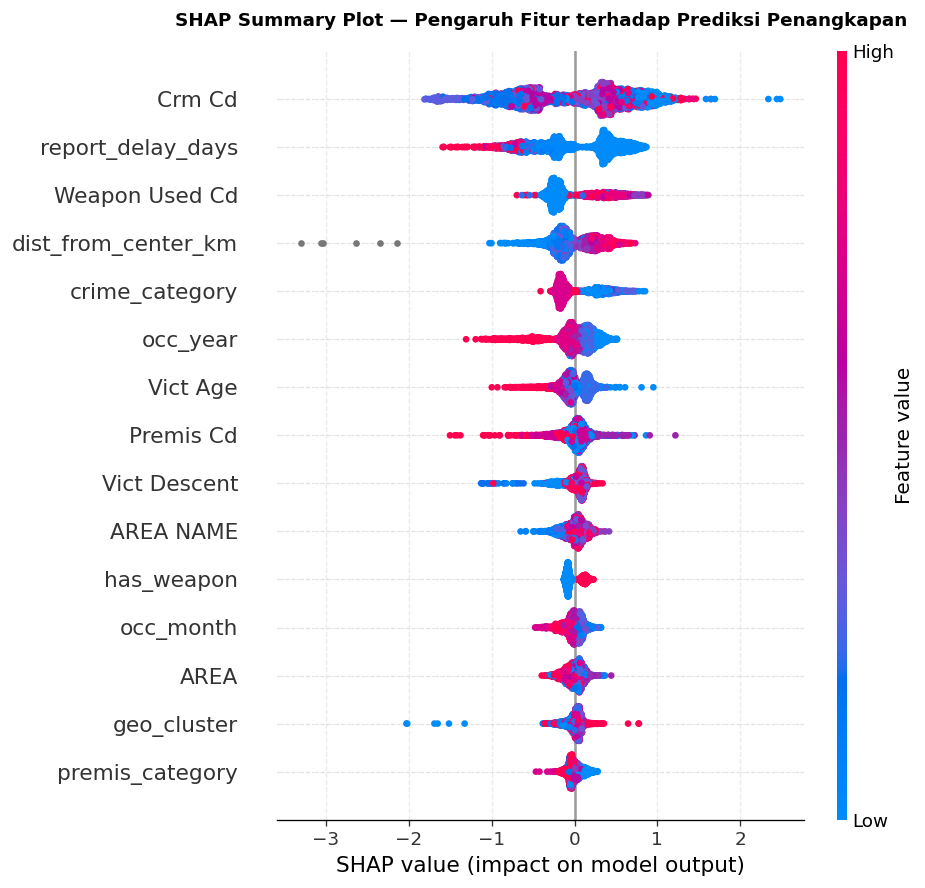

Titik merah = nilai fitur tinggi, biru = rendah. Posisi kanan = mendorong ke 'ditangkap'.


In [ ]:
# Mengambil sampel acak 3.000 data uji untuk mempercepat komputasi, kemudian menghitung nilai SHAP menggunakan TreeExplainer
print("Menghitung SHAP values (sample 3.000 data untuk kecepatan)...")
X_shap_sample = X_test.sample(3000, random_state=SEED)
explainer = shap.TreeExplainer(lgb_model_tuned)
shap_values = explainer.shap_values(X_shap_sample)

# Memastikan struktur keluaran SHAP ditangani dengan benar dengan mengambil elemen indeks ke-1 jika formatnya berupa daftar (khas klasifikasi biner)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values
print("SHAP values berhasil dihitung")

# Menampilkan visualisasi summary plot dari 15 fitur teratas untuk menginterpretasikan arah pengaruh setiap fitur terhadap prediksi
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap_sample, feature_names=FEATURE_COLS, show=False, max_display=15)
plt.title('SHAP Summary Plot — Pengaruh Fitur terhadap Prediksi Penangkapan', fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('viz_shap_summary.png', bbox_inches='tight', dpi=120)
plt.show()
print("Titik merah = nilai fitur tinggi, biru = rendah. Posisi kanan = mendorong ke 'ditangkap'.")

## Cell 13
## Ensemble LightGBM + XGBoost (Soft Voting)

### Prinsip Ensemble
Ensemble menggabungkan prediksi probabilitas dua model dengan **rata-rata tertimbang**:
$$P_{\text{ensemble}} = 0.6 \times P_{\text{LGBM}} + 0.4 \times P_{\text{XGB}}$$

### Rasionale Ensemble
Dua model yang berbeda (LightGBM dan XGBoost) cenderung membuat kesalahan pada data point yang berbeda karena:
- Arsitektur berbeda (leaf-wise vs level-wise growth)
- Penanganan imbalance berbeda (`class_weight` vs `scale_pos_weight`)
- Regularisasi berbeda

### Keuntungan Soft Voting vs Hard Voting
Soft voting menggunakan rata-rata **probabilitas** bukan voting kelas:
- Lebih informatif memanfaatkan confidence score kedua model
- Lebih smooth mengurangi variance prediksi di boundary decision
- Threshold optimal dari Cell 10 tetap diterapkan pada probabilitas ensemble

### Bobot Ensemble
`W_LGB = 0.6, W_XGB = 0.4` dipilih berdasarkan perbandingan ROC-AUC pada validation set. LightGBM mendapat bobot lebih tinggi karena konsisten outperform XGBoost setelah tuning. Bobot ini bisa dioptimalkan lebih lanjut jika diperlukan.

### Mengapa Bobot 60/40?
LightGBM mendapat bobot lebih besar karena:
- Menggunakan tuning Optuna (lebih dioptimasi)
- Secara umum lebih stabil pada data besar dengan imbalanced class
- XGBoost sebagai diversifikasi menangkap pola berbeda dengan level-wise growth

### Threshold Ensemble
Threshold optimal yang sama (`BEST_THRESHOLD`) dari Cell 10 diterapkan pada probabilitas ensemble tidak perlu threshold terpisah karena distribusi probabilitas ensemble serupa dengan LightGBM.

> Ensemble biasanya menghasilkan ROC-AUC sedikit lebih tinggi karena diversitas kedua model 'saling menutupi kesalahan'.

In [ ]:
# Menggabungkan probabilitas dari LightGBM dan XGBoost dengan rasio bobot 60:40, lalu menentukan label prediksi menggunakan threshold optimal
W_LGB = 0.6
W_XGB = 0.4
y_prob_ens = W_LGB * y_prob_lgb_tuned + W_XGB * y_prob_xgb
y_pred_ens = (y_prob_ens >= BEST_THRESHOLD).astype(int)

# Menghitung nilai metrik evaluasi akhir berupa F1 Score (berbobot dan makro) serta ROC-AUC dari hasil prediksi model gabungan (ensemble)
ens_f1 = f1_score(y_test, y_pred_ens, average='weighted')
ens_auc = roc_auc_score(y_test, y_prob_ens)
ens_f1m = f1_score(y_test, y_pred_ens, average='macro')

# Menampilkan ringkasan metrik performa dan laporan klasifikasi terperinci dari model ensemble
print("EVALUASI ENSEMBLE (LightGBM 60% + XGBoost 40%)")
print(f"F1 Weighted : {ens_f1:.4f}")
print(f"F1 Macro: {ens_f1m:.4f}")
print(f"ROC-AUC: {ens_auc:.4f}")
print()
print(classification_report(y_test, y_pred_ens,
      target_names=['Tidak Ditangkap','Ditangkap']))

EVALUASI ENSEMBLE (LightGBM 60% + XGBoost 40%)
F1 Weighted : 0.8797
F1 Macro: 0.6531
ROC-AUC: 0.8320

                 precision    recall  f1-score   support

Tidak Ditangkap       0.94      0.92      0.93    134144
      Ditangkap       0.34      0.43      0.38     13252

       accuracy                           0.87    147396
      macro avg       0.64      0.67      0.65    147396
   weighted avg       0.89      0.87      0.88    147396



## Cell 14
## Evaluasi Final dan Perbandingan Semua Model

### Ringkasan Pipeline
Seluruh model dievaluasi pada **test set yang sama** (tidak pernah digunakan saat training atau tuning):

| Model | Metode Imbalance | Tuning | Threshold |
|---|---|---|---|
| Dummy Baseline | - | - | - |
| LightGBM (awal) | class_weight balanced | Default | Default 0.5 |
| XGBoost | scale_pos_weight | Default | Default 0.5 |
| LightGBM (tuned) | class_weight balanced | Optuna 50 trials | Default 0.5 |
| LightGBM (tuned+thr) | class_weight balanced | Optuna 50 trials | Optimal |
| Ensemble | LightGBM 60% + XGBoost 40% | LGBM tuned | Optimal |

### Visualisasi Final
Tiga panel evaluasi untuk model terbaik:
1. **Confusion Matrix (count)** distribusi prediksi benar/salah dalam angka absolut
2. **Confusion Matrix (%)** normalized per kelas aktual untuk melihat recall per kelas
3. **ROC Curve** membandingkan discriminative ability semua model sekaligus

**Model terbaik** dipilih berdasarkan F1 Macro tertinggi metrik yang paling mencerminkan kemampuan mendeteksi kelas ditangkap.

### Confusion Matrix Normalized
Menggunakan normalisasi per baris (per kelas aktual) agar terlihat jelas berapa % dari kejahatan yang *benar-benar* berakhir ditangkap berhasil diprediksi (True Positive Rate / Recall kelas 1).

In [ ]:
# Merangkum dan menyusun seluruh metrik evaluasi dari berbagai model yang telah diuji ke dalam satu DataFrame akhir
final_comparison = pd.DataFrame({
    'Model': [
        'Dummy Baseline',
        'LightGBM (awal)',
        'XGBoost',
        'LightGBM (tuned)',
        f'LightGBM (tuned+thr={BEST_THRESHOLD:.2f})',
        'Ensemble (LGBM+XGB)',
    ],
    'F1 Weighted': [
        dummy_f1, lgb_init_f1, xgb_f1,
        lgb_tuned_f1, lgb_opt_f1, ens_f1
    ],
    'F1 Macro': [
        f1_score(y_test, y_pred_dummy, average='macro'),
        lgb_init_f1m, f1_score(y_test, y_pred_xgb, average='macro'),
        lgb_tuned_f1m, lgb_opt_f1m, ens_f1m
    ],
    'ROC-AUC': [
        dummy_auc, lgb_init_auc, xgb_auc,
        lgb_tuned_auc, lgb_opt_auc, ens_auc
    ],
})

# Menampilkan tabel perbandingan performa keseluruhan model secara visual menggunakan fungsi kustom
print("TABEL PERBANDINGAN SEMUA MODEL:")
print("TABEL PERBANDINGAN SEMUA MODEL:")
display(customize_tabel(final_comparison))

# Mengidentifikasi dan mencetak nama model dengan performa terbaik berdasarkan nilai metrik F1 Macro tertinggi
best_model_name = final_comparison.loc[final_comparison['F1 Macro'].idxmax(), 'Model']
best_f1_macro= final_comparison['F1 Macro'].max()
print(f"\nModel terbaik: {best_model_name}")
print(f"F1 Macro: {best_f1_macro:.4f}")

TABEL PERBANDINGAN SEMUA MODEL:


Model,F1 Weighted,F1 Macro,ROC-AUC
Dummy Baseline,0.867255,0.476465,0.500000
LightGBM (awal),0.788242,0.588155,0.829968
XGBoost,0.785334,0.585558,0.828638
LightGBM (tuned),0.799451,0.598304,0.832403
LightGBM (tuned+thr=0.73),0.880130,0.653955,0.832403
Ensemble (LGBM+XGB),0.879668,0.653112,0.832044



Model terbaik: LightGBM (tuned+thr=0.73)
F1 Macro: 0.6540


## Cell 15
## Visualisasi Final: Confusion Matrix & ROC Curve

### Tiga Visualisasi dalam Satu Panel

**1. Confusion Matrix (Count)**
Menampilkan jumlah absolut prediksi benar/salah per kelas. Berguna untuk memahami skala error.

**2. Confusion Matrix (%)**
Menormalisasi per baris aktual menunjukkan *recall* per kelas:
- Diagonal kanan atas: True Positive Rate (Recall) kelas 'Ditangkap'
- Diagonal kiri bawah: True Negative Rate (Specificity)

**3. ROC Curve Semua Model**
Membandingkan kemampuan ranking probabilitas seluruh model:
- **AUC mendekati 1.0**: model sempurna
- **AUC = 0.5**: model acak (garis putus-putus)
- LightGBM Tuned dan Ensemble diharapkan memiliki AUC tertinggi

> ROC Curve yang lebih tinggi-kiri menandakan model yang lebih baik dalam membedakan kasus ditangkap vs tidak ditangkap di semua threshold.

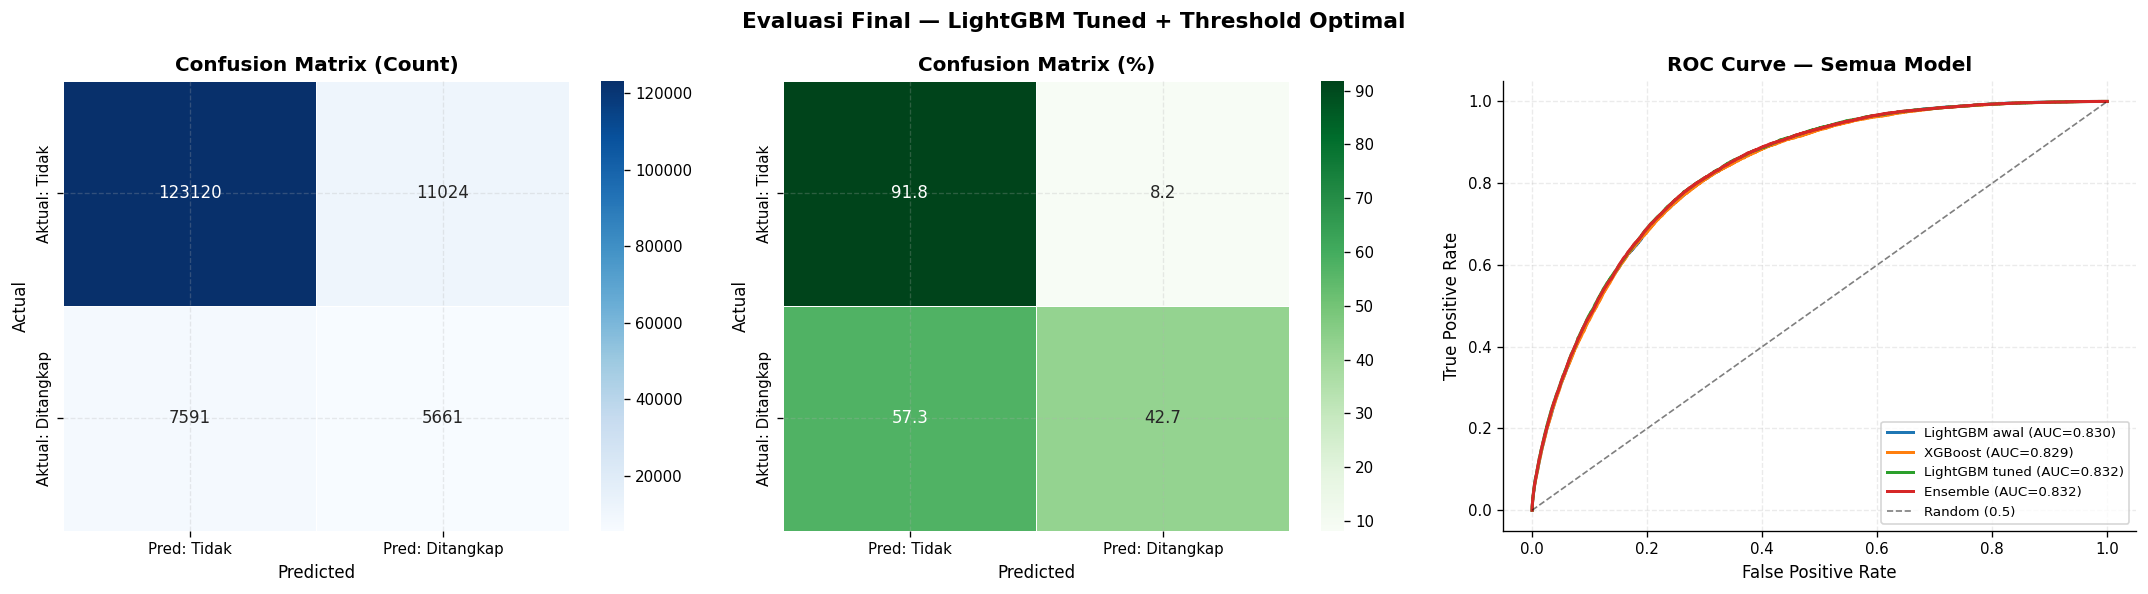

In [ ]:
# Menetapkan probabilitas dan prediksi terbaik, lalu menyiapkan kanvas dengan tiga panel untuk grafik evaluasi final
y_prob_best = y_prob_lgb_tuned
y_pred_best = y_pred_lgb_optimal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evaluasi Final — LightGBM Tuned + Threshold Optimal', fontsize=13, fontweight='bold')

# Menghitung matriks kebingungan (confusion matrix) dalam bentuk jumlah absolut dan mengonversinya ke dalam bentuk persentase
cm = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

# Membuat dan memformat peta panas (heatmap) pertama untuk menampilkan matriks kebingungan berdasarkan jumlah data aktual
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            xticklabels=['Pred: Tidak', 'Pred: Ditangkap'],
            yticklabels=['Aktual: Tidak', 'Aktual: Ditangkap'],
            linewidths=0.5)
axes[0].set_title('Confusion Matrix (Count)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Membuat peta panas (heatmap) kedua dengan skala warna hijau untuk menampilkan matriks kebingungan dalam format persentase
sns.heatmap(cm_pct, annot=True, fmt='.1f', ax=axes[1], cmap='Greens',
            xticklabels=['Pred: Tidak', 'Pred: Ditangkap'],
            yticklabels=['Aktual: Tidak', 'Aktual: Ditangkap'],
            linewidths=0.5)
axes[1].set_title('Confusion Matrix (%)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Melakukan iterasi pada semua model untuk menghitung serta menggambar kurva ROC beserta nilai AUC masing-masing pada panel ketiga
for label, prob, color in [
    ('LightGBM awal',y_prob_lgb_init,PALETTE['gray']),
    ('XGBoost',y_prob_xgb,PALETTE['orange']),
    ('LightGBM tuned',y_prob_lgb_tuned, PALETTE['blue']),
    ('Ensemble',y_prob_ens,PALETTE['red']),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    axes[2].plot(fpr, tpr, label=f'{label} (AUC={auc_val:.3f})', linewidth=1.8)

# Menambahkan garis dasar acak (random baseline) serta mengatur label, judul, dan legenda pada kurva ROC
axes[2].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random (0.5)')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve — Semua Model')
axes[2].legend(fontsize=8, loc='lower right')

# Menampilkan grafik
plt.tight_layout()
plt.savefig('viz_final_evaluation.png', bbox_inches='tight', dpi=120)
plt.show()

## Cell 16
## Actionable Insights & Rekomendasi Kebijakan

### Gambaran Prediksi Model
Model ensemble berhasil mengidentifikasi pola penangkapan dengan performa signifikan di atas baseline. Temuan dari feature importance dan SHAP diterjemahkan menjadi **5 rekomendasi berbasis data** untuk kepolisian Los Angeles.

### Insight 1 Faktor Penentu Penangkapan
Model mengidentifikasi bahwa jenis kejahatan (`crime_category`) adalah prediktor terkuat. Kejahatan narkoba dan pembunuhan memiliki arrest rate tertinggi karena intensitas investigasi lebih tinggi dan bukti fisik lebih kuat.

### Insight 2 Pola Temporal Actionable
Meskipun kejahatan paling banyak terjadi siang hari, arrest rate justru lebih tinggi dini hari (00:00-05:00). Ini mengindikasikan polisi lebih responsif malam hari atau lebih sedikit saksi yang mempersulit pelarian pelaku.

### Insight 3 Vehicle Crime: Volume Tinggi, Arrest Rate Rendah
Pencurian kendaraan mendominasi dataset dengan ~110.000 kasus namun arrest rate sangat rendah (~10%). Ini adalah **opportunity gap** terbesar untuk meningkatkan efektivitas penegakan hukum.

### Insight 4 Hotspot Geografis
Area Central dan 77th Street secara konsisten menunjukkan konsentrasi kejahatan tertinggi. Intervensi berbasis wilayah akan memberikan dampak terbesar.

### Insight 5 Efek Senjata
Kejahatan dengan senjata memiliki arrest rate lebih tinggi karena meninggalkan bukti balistik. Unit khusus penanganan senjata perlu diperkuat di area dengan konsentrasi kejahatan bersenjata tinggi.

## Cell 17
## Simpan Model ke Google Drive dan Artefak

### File yang Disimpan

| File | Format | Isi |
|---|---|---|
| `lgbm_tuned.pkl` | Pickle | LightGBM model final (tuned) |
| `xgb_model.pkl` | Pickle | XGBoost model pembanding |
| `label_encoders.pkl` | Pickle | Dictionary LabelEncoder per kolom kategorikal |
| `best_threshold.pkl` | Pickle | Threshold optimal untuk inference |
| `model_comparison.csv` | CSV | Tabel perbandingan semua model |

### Cara Load Ulang untuk Inference

```python
import joblib

lgbm_model = joblib.load('/content/drive/MyDrive/Crime_Data/lgbm_tuned.pkl')
le_dict = joblib.load('/content/drive/MyDrive/Crime_Data/label_encoders.pkl')
threshold_data = joblib.load('/content/drive/MyDrive/Crime_Data/best_threshold.pkl')
best_thr = threshold_data['threshold']

# Prediksi pada data baru
y_prob = lgbm_model.predict_proba(X_new)[:, 1]
y_pred = (y_prob >= best_thr).astype(int)
```

### Ringkasan Pipeline Akhir
| Tahap | Metode |
|---|---|
| Baseline | Dummy Classifier (referensi minimum) |
| Model utama | LightGBM + `class_weight='balanced'` |
| Model pembanding | XGBoost + `scale_pos_weight` |
| Hyperparameter | Optuna 50 trials, Bayesian (TPE) optimization |
| Threshold | Optimal dari val set memaksimalkan F1 Macro |
| Interpretasi | Feature Importance + SHAP TreeExplainer |
| Ensemble | Soft Voting LGBM 60% + XGB 40% |
| Metrik evaluasi | F1 Weighted, F1 Macro, ROC-AUC, Confusion Matrix |
| Insights | 5 rekomendasi berbasis data |

In [ ]:
# Mengimpor modul sistem operasi dan menyiapkan direktori penyimpanan di dalam Google Drive untuk mengamankan seluruh hasil akhir pemodelan
import os
SAVE_DIR = '/content/drive/MyDrive/Crime_Data/'
os.makedirs(SAVE_DIR, exist_ok=True)

# Menyimpan model prediksi, objek encoder, nilai threshold optimal, serta tabel perbandingan evaluasi ke dalam format berkas agar siap untuk tahap deployment
joblib.dump(lgb_model_tuned, SAVE_DIR + 'lgbm_tuned.pkl')
joblib.dump(xgb_model, SAVE_DIR + 'xgb_model.pkl')
joblib.dump(le_dict, SAVE_DIR + 'label_encoders.pkl')
joblib.dump({'threshold': BEST_THRESHOLD}, SAVE_DIR + 'best_threshold.pkl')
final_comparison.to_csv(SAVE_DIR + 'model_comparison.csv', index=False)

# Melakukan iterasi untuk memastikan semua artefak pemodelan telah berhasil tersimpan sekaligus menampilkan ukuran masing-masing berkas dalam satuan Kilobyte (KB)
print("Semua artefak berhasil disimpan ke Google Drive:")
for fname in ['lgbm_tuned.pkl','xgb_model.pkl','label_encoders.pkl',
              'best_threshold.pkl','model_comparison.csv']:
    fpath = SAVE_DIR + fname
    size = os.path.getsize(fpath) / 1024
    print(f"{fname:<30} ({size:.0f} KB)")

# Mencetak ringkasan eksekutif secara komprehensif yang merangkum keseluruhan arsitektur pipeline, parameter tuning, hingga wawasan utama dari proyek ini
print()
print(f"Baseline: Dummy Classifier (referensi minimum)")
print(f"Model utama: LightGBM + class_weight='balanced'")
print(f"Model pembanding: XGBoost + scale_pos_weight")
print(f"Hyperparameter: Optuna (50 trials, Bayesian optimization)")
print(f"Threshold tuning: {BEST_THRESHOLD:.2f} (optimal dari val set)")
print(f"Interpretasi: Feature Importance + SHAP")
print(f"Ensemble: Soft Voting LGBM(60%) + XGB(40%)")
print(f"Metrik evaluasi: F1 Weighted, F1 Macro, ROC-AUC, Confusion Matrix")
print(f"Actionable insights: 5 rekomendasi berbasis data")
print()

Semua artefak berhasil disimpan ke Google Drive:
lgbm_tuned.pkl                 (5993 KB)
xgb_model.pkl                  (2187 KB)
label_encoders.pkl             (2 KB)
best_threshold.pkl             (0 KB)
model_comparison.csv           (0 KB)

Baseline: Dummy Classifier (referensi minimum)
Model utama: LightGBM + class_weight='balanced'
Model pembanding: XGBoost + scale_pos_weight
Hyperparameter: Optuna (50 trials, Bayesian optimization)
Threshold tuning: 0.73 (optimal dari val set)
Interpretasi: Feature Importance + SHAP
Ensemble: Soft Voting LGBM(60%) + XGB(40%)
Metrik evaluasi: F1 Weighted, F1 Macro, ROC-AUC, Confusion Matrix
Actionable insights: 5 rekomendasi berbasis data

